In [1]:
# import library
import numpy as np  
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import math

pd.set_option("display.max_colwidth", 0)

# data splitting
from sklearn.model_selection import train_test_split 

# scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# encoding
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder, OrdinalEncoder

# missing values
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer

# binning
from sklearn.preprocessing import KBinsDiscretizer

# polynomial features
from sklearn.preprocessing import PolynomialFeatures

# column transfornmer
from sklearn.compose import ColumnTransformer

# pipeline
from sklearn.pipeline import Pipeline

# cross validation
from sklearn.model_selection import cross_val_score

# hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# modeling
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import  KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor
from xgboost.sklearn import XGBRegressor

# SHAP

import shap

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score

### **Business Problem Understanding**

**Background and Problem Statement**

Platform A, a South Korean real estate platform, enables users to list apartments for rent or sale, allowing sellers to set their own prices. However, Sellers struggle to balance competitiveness and profitability, as overpriced listings deter buyers, while underpriced ones lead to lost revenue. This challenge is exacerbated by the complexity of the real estate market, where apartment prices are influenced by internal factors (e.g., size, age, amenities) and external factors (e.g., proximity to transportation, schools, and public services).


Without a systematic approach to pricing, sellers on Platform A rely on intuition or incomplete information, leading to suboptimal pricing decisions and prolonged listing times.  

The **inaccuracy in apartment pricing on Platform A** can results in:  
1. **Overpriced listings**: Apartments priced 10-20% above market value remain unsold for extended periods (e.g., 30+ days).  
2. **Underpriced listings**: Apartments priced 10-15% below market value lead to significant revenue loss for sellers. 

Further Readings: 
- [Consequences of Over and Under Pricing your Rental](https://www.avenuepropertymgmt.com/blog/consequences-of-over-and-under-pricing-your-rental)
- [The Price of Overpricing: How Listing Price Impacts Time on Market - Zillow Research](https://www.zillow.com/research/overpricing-impacts-time-market-12476/)

**Stakeholder**

The primary stakeholders are apartment owners in Daegu who actively rent or sell their properties on Platform A. These individuals rely on the platform to set competitive prices for their apartments but often struggle to accurately align their listings with market trends.


**Goals**

Our goal is to empower apartment owners on Platform A to make informed pricing decisions by leveraging historical data and current market trends. Using machine learning, we aim to analyze key factors such as apartment size, age, amenities, and location to provide accurate price predictions.

**For the real estate agent or landlords**, such as a listing service for apartments, offering a fair and accurate pricing tool will likely attract more property listings. With more listings, the platform can increase the number of transactions, which will ultimately boost the platform’s revenue generated from booking and listing fees.

By optimizing apartment prices through this tool, both apartment owners and the platform stand to benefit, leading to higher profits, more transactions, and a more efficient housing market.

**Metrics and Their Implications**

1. **Mean Absolute Error (MAE)**
- **Definition**: Measures the average absolute difference between predicted and actual prices (in won).
- **Implication**: Indicates the **average error** in predictions without considering direction (over or under).

2. **Root Mean Squared Error (RMSE)**
- **Definition**: The square root of MSE, giving the error in the same units as the target (won).
- **Implication**: Shows how much the predictions are off **on average**, with more importance on larger errors.

3. **Mean Absolute Percentage Error (MAPE)**
- **Definition**: Measures the average percentage difference between predicted and actual prices.
- **Implication**: Implies how **accurate** the predictions are as a percentage of the actual value.

4. **R-squared (R²)**
- **Definition**: Indicates how well the model explains the variation in apartment prices (from 0 to 1).
- **Implication**: Implies the **proportion of variance** explained by the model; the higher, the better.



# Data Understanding

Data is a collection of apartment in the region of Daegu, South Korea

### Apartment Features

| Feature                          | Description                                      |
|----------------------------------|--------------------------------------------------|
| **Hallway Type**                 | Apartment type                                   |
| **TimeToSubway**                 | Time needed to the nearest subway station        |
| **SubwayStation**                | The name of the nearest subway station           |
| **N_FacilitiesNearBy(ETC)**      | The number of facilities nearby                  |
| **N_FacilitiesNearBy(PublicOffice)** | The number of public office facilities nearby  |
| **N_SchoolNearBy(University)**   | The number of universities nearby                |
| **N_Parkinglot(Basement)**      | The number of the parking lot                    |
| **YearBuilt**                    | The year the apartment was built                 |
| **N_FacilitiesInApt**            | Number of facilities in the apartment            |
| **Size(sqft)**                   | The apartment size (in square feet)              |
| **SalePrice**                    | The apartment price (Won)                        |


- [ZigBang](https://www.zigbang.com/)
- [DaBang](https://www.dabangapp.com/)
- [Peterpanz](https://www.peterpanz.com/)

The features that were selected in this dataset include features that are typically seen in listings, as evidenced by these three popular real estate websites in Korea. As a result, we will make use of it in order to predict the cost of our model.

Example:
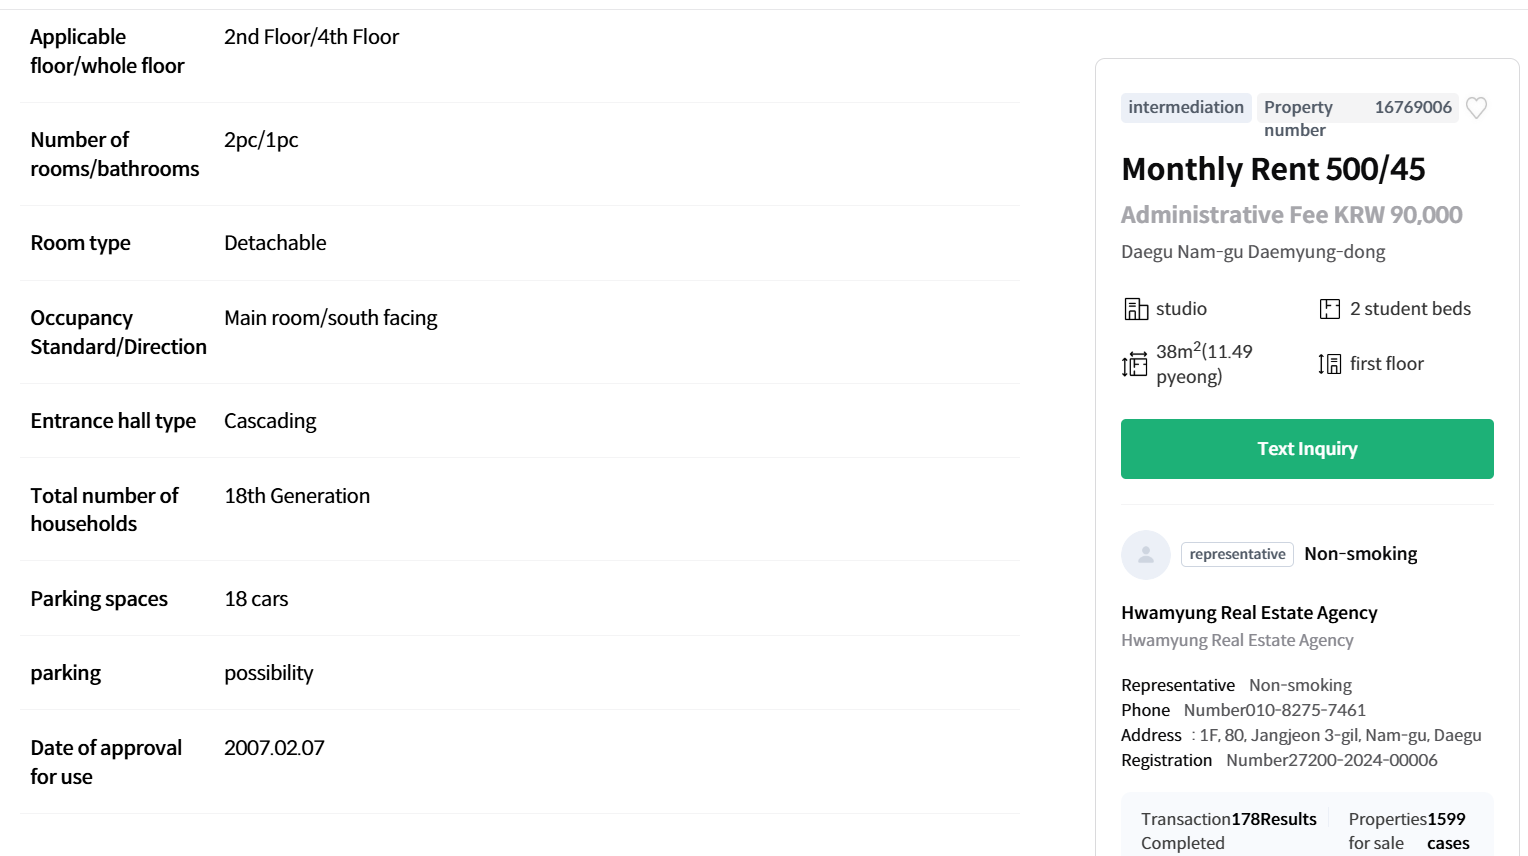
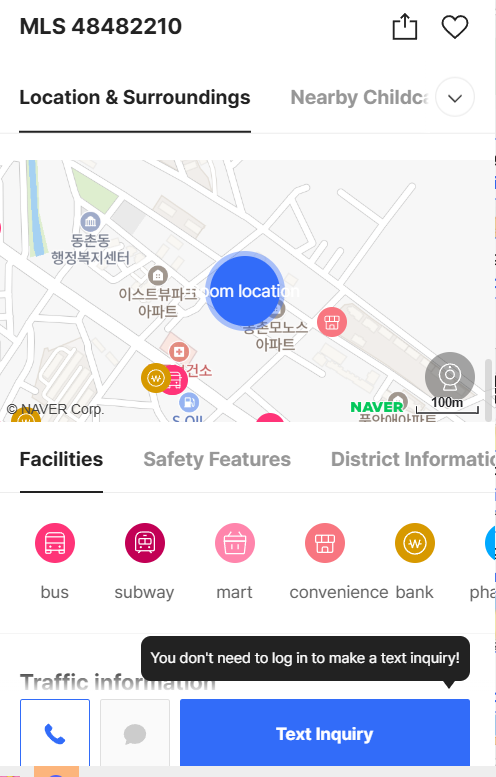


In [2]:
df = pd.read_csv('data_daegu_apartment.csv')
df.head()

,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice
0,terraced,0-5min,Kyungbuk_uni_hospital,0.0,3.0,2.0,1270.0,2007,10,1387,346017
1,terraced,10min~15min,Kyungbuk_uni_hospital,1.0,5.0,1.0,0.0,1986,4,914,150442
2,mixed,15min~20min,Chil-sung-market,1.0,7.0,3.0,56.0,1997,5,558,61946
3,mixed,5min~10min,Bangoge,5.0,5.0,4.0,798.0,2005,7,914,165486
4,terraced,0-5min,Sin-nam,0.0,1.0,2.0,536.0,2006,5,1743,311504


# EDA (Exploratory Data Analysis)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   HallwayType                       4123 non-null   object 
 1   TimeToSubway                      4123 non-null   object 
 2   SubwayStation                     4123 non-null   object 
 3   N_FacilitiesNearBy(ETC)           4123 non-null   float64
 4   N_FacilitiesNearBy(PublicOffice)  4123 non-null   float64
 5   N_SchoolNearBy(University)        4123 non-null   float64
 6   N_Parkinglot(Basement)            4123 non-null   float64
 7   YearBuilt                         4123 non-null   int64  
 8   N_FacilitiesInApt                 4123 non-null   int64  
 9   Size(sqf)                         4123 non-null   int64  
 10  SalePrice                         4123 non-null   int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 354.4+ KB


## Missing Values

In [4]:
df.isna().sum()

HallwayType                         0
TimeToSubway                        0
SubwayStation                       0
N_FacilitiesNearBy(ETC)             0
N_FacilitiesNearBy(PublicOffice)    0
N_SchoolNearBy(University)          0
N_Parkinglot(Basement)              0
YearBuilt                           0
N_FacilitiesInApt                   0
Size(sqf)                           0
SalePrice                           0
dtype: int64

In [5]:
list_columns = [x for x in df.columns]
list_unique = []
for x in df.columns:
    y = df[x].unique()
    list_unique.append(y)

df_unique = pd.DataFrame(list_columns)
df_unique['unqiue']=list_unique
df_unique

,0,unqiue
0,HallwayType,"[terraced, mixed, corridor]"
1,TimeToSubway,"[0-5min, 10min~15min, 15min~20min, 5min~10min, no_bus_stop_nearby]"
2,SubwayStation,"[Kyungbuk_uni_hospital, Chil-sung-market, Bangoge, Sin-nam, Banwoldang, no_subway_nearby, Myung-duk, Daegu]"
3,N_FacilitiesNearBy(ETC),"[0.0, 1.0, 5.0, 2.0]"
4,N_FacilitiesNearBy(PublicOffice),"[3.0, 5.0, 7.0, 1.0, 4.0, 2.0, 6.0, 0.0]"
5,N_SchoolNearBy(University),"[2.0, 1.0, 3.0, 4.0, 5.0, 0.0]"
6,N_Parkinglot(Basement),"[1270.0, 0.0, 56.0, 798.0, 536.0, 605.0, 203.0, 108.0, 1174.0, 930.0, 475.0, 184.0, 400.0, 218.0, 1321.0, 524.0, 76.0, 79.0, 181.0, 18.0]"
7,YearBuilt,"[2007, 1986, 1997, 2005, 2006, 2009, 2014, 1993, 2013, 2008, 2015, 1978, 1985, 1992, 2003, 1980]"
8,N_FacilitiesInApt,"[10, 4, 5, 7, 2, 9, 8, 1, 3]"
9,Size(sqf),"[1387, 914, 558, 1743, 1334, 572, 910, 288, 1131, 843, 1160, 644, 829, 743, 868, 1629, 1690, 1273, 1483, 156, 1412, 1394, 903, 676, 355, 1419, 640, 1184, 1167, 135, 818, 206, 1643, 907, 1377, 2337, 1252, 451, 587, 811, 2056, 508, 576, 1366, 1103, 426, 281, 1327, 1092, 857, 1928, 1149, 1088, 1288, 1761, 1437, 1291, 2092, 636, 814, 871, 1519, 1444, 1451, 1448, 1313, 1256, 1796, 1192, 1035, 846, 273, 277, 779, 498, 736, 138, 430, 213, 163, 1369, 192, 547, 839, 160, 793, 1085, 1060, 832]"


In [7]:
df['YearBuilt'].min(),df['YearBuilt'].max()

(1978, 2015)

In [8]:
df['YearBuilt'].unique()

array([2007, 1986, 1997, 2005, 2006, 2009, 2014, 1993, 2013, 2008, 2015,
       1978, 1985, 1992, 2003, 1980], dtype=int64)

In [6]:
df.duplicated().sum()

1422

In [7]:
df.drop_duplicates(inplace=True)

## Outliers

C:\Users\User\AppData\Local\Temp\ipykernel_33284\1893064839.py:28: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.4, wspace=0.4)


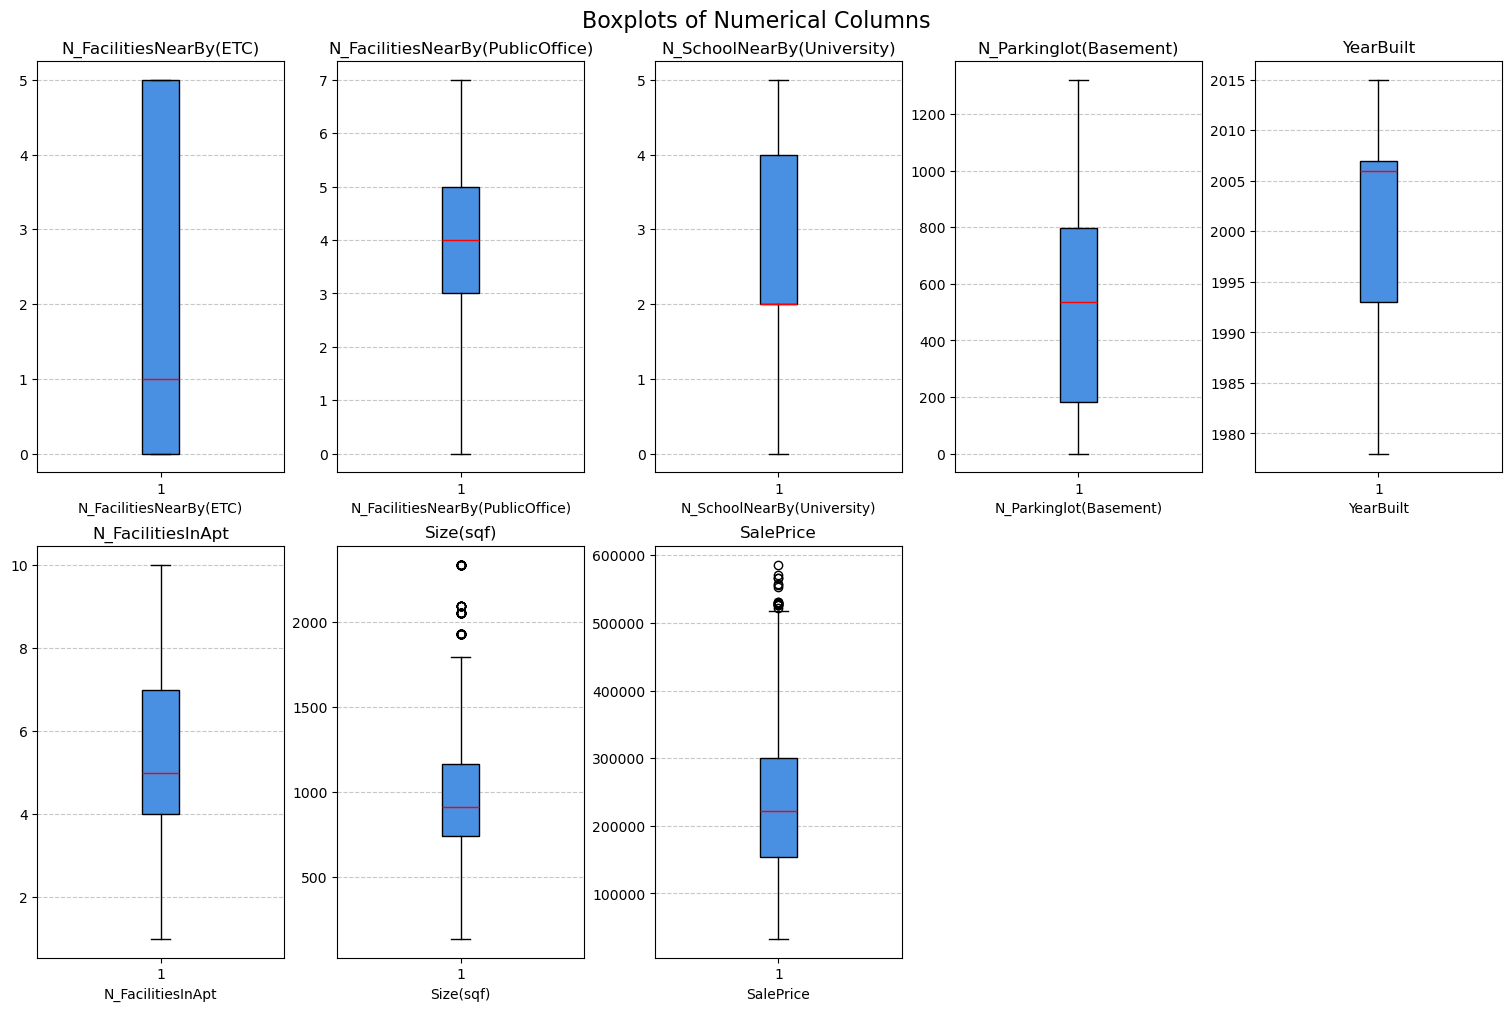

In [8]:

num_columns = df.select_dtypes(include=['number']).columns  # Select numerical columns
num_cols = len(num_columns)

# Determine grid size
cols = 5 # Fixed number of columns in the subplot grid
rows = math.ceil(num_cols / cols)  # Calculate the required rows

# Create the figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Plot each boxplot
for i, col in enumerate(num_columns):
    axes[i].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='#4a90e2', color='black'), 
                    medianprops=dict(color='red'))
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Add an overall title
fig.suptitle('Boxplots of Numerical Columns', fontsize=16)

plt.subplots_adjust(hspace=0.4, wspace=0.4)
# Display the plot
plt.show()

In [9]:
q1_size = df['Size(sqf)'].median()
q3_size = df['Size(sqf)'].quantile(0.75)

iqr_size = q3_size-q1_size
upper_size = q3_size + (iqr_size*1.5)

In [10]:
upper_size

1552.5

In [11]:
df[df['Size(sqf)']>upper_size]

,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice
4,terraced,0-5min,Sin-nam,0.0,1.0,2.0,536.0,2006,5,1743,311504
27,terraced,0-5min,Banwoldang,0.0,4.0,1.0,605.0,2007,5,1629,442477
28,terraced,0-5min,Banwoldang,0.0,4.0,1.0,605.0,2007,5,1690,435398
42,terraced,0-5min,Banwoldang,0.0,4.0,1.0,605.0,2007,5,1690,476106
52,terraced,0-5min,Banwoldang,0.0,4.0,1.0,605.0,2007,5,1690,442477
...,...,...,...,...,...,...,...,...,...,...,...
4043,terraced,0-5min,Kyungbuk_uni_hospital,0.0,3.0,2.0,1270.0,2007,10,1643,362601
4061,terraced,0-5min,Sin-nam,0.0,1.0,2.0,536.0,2006,5,1743,380530
4074,mixed,15min~20min,Myung-duk,5.0,6.0,5.0,536.0,1993,4,2337,254424
4104,mixed,15min~20min,Myung-duk,5.0,6.0,5.0,536.0,1993,4,1761,221681


In [12]:
df.shape

(2701, 11)

 There are no **extreme outliers** and considering the number of remaining rows, we will not cut any rows. We will be using **2701** data.

## Data Distribution

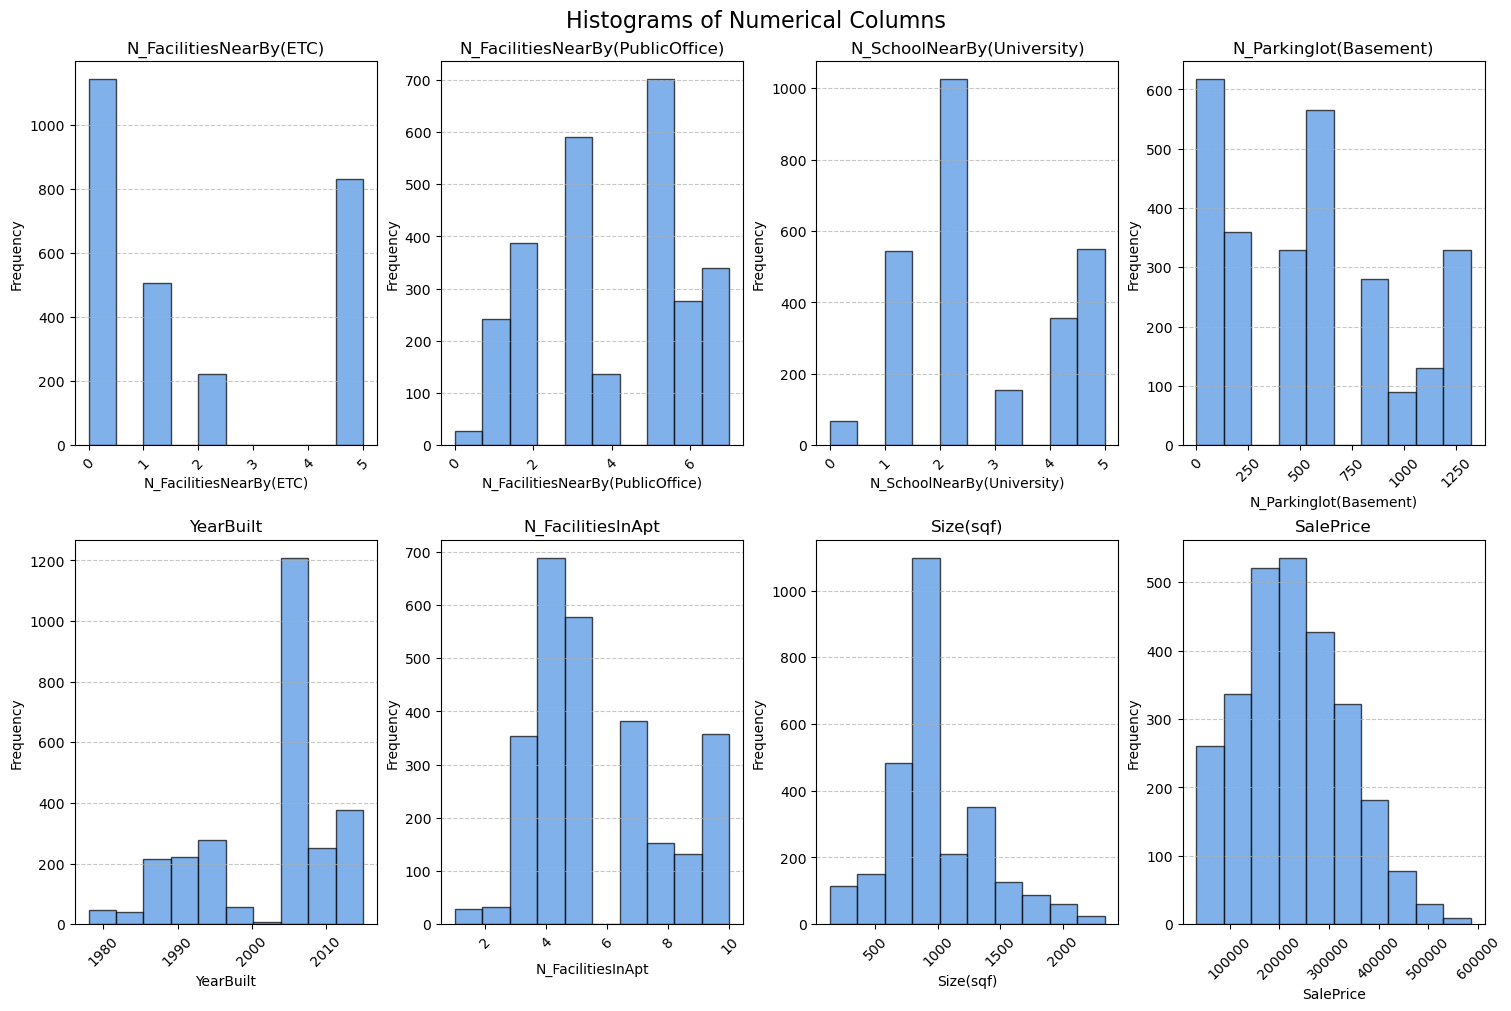

In [13]:

num_columns = df.select_dtypes(include=['number']).columns  # Select numerical columns
num_cols = len(num_columns)

# Determine grid size
cols = 4  # Fixed number of columns in the subplot grid
rows = math.ceil(num_cols / cols)  # Calculate the required rows

# Create the figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Plot each histogram
for i, col in enumerate(num_columns):
    axes[i].hist(df[col].dropna(), bins=10, color='#4a90e2', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Add an overall title
fig.suptitle('Histograms of Numerical Columns', fontsize=16)

# Display the plot
plt.show()

## **Correlation Matrix (using spearman method)**

In [14]:
df_corr= df.select_dtypes(include=['number'])
df_corr

,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice
0,0.0,3.0,2.0,1270.0,2007,10,1387,346017
1,1.0,5.0,1.0,0.0,1986,4,914,150442
2,1.0,7.0,3.0,56.0,1997,5,558,61946
3,5.0,5.0,4.0,798.0,2005,7,914,165486
4,0.0,1.0,2.0,536.0,2006,5,1743,311504
...,...,...,...,...,...,...,...,...
4116,0.0,1.0,2.0,536.0,2006,5,818,290265
4117,5.0,6.0,5.0,536.0,1993,4,1761,345132
4118,0.0,3.0,2.0,475.0,2008,8,914,323008
4119,5.0,6.0,5.0,536.0,1993,4,1451,242477


Text(0.5, 1.0, 'Correlation Matrix')

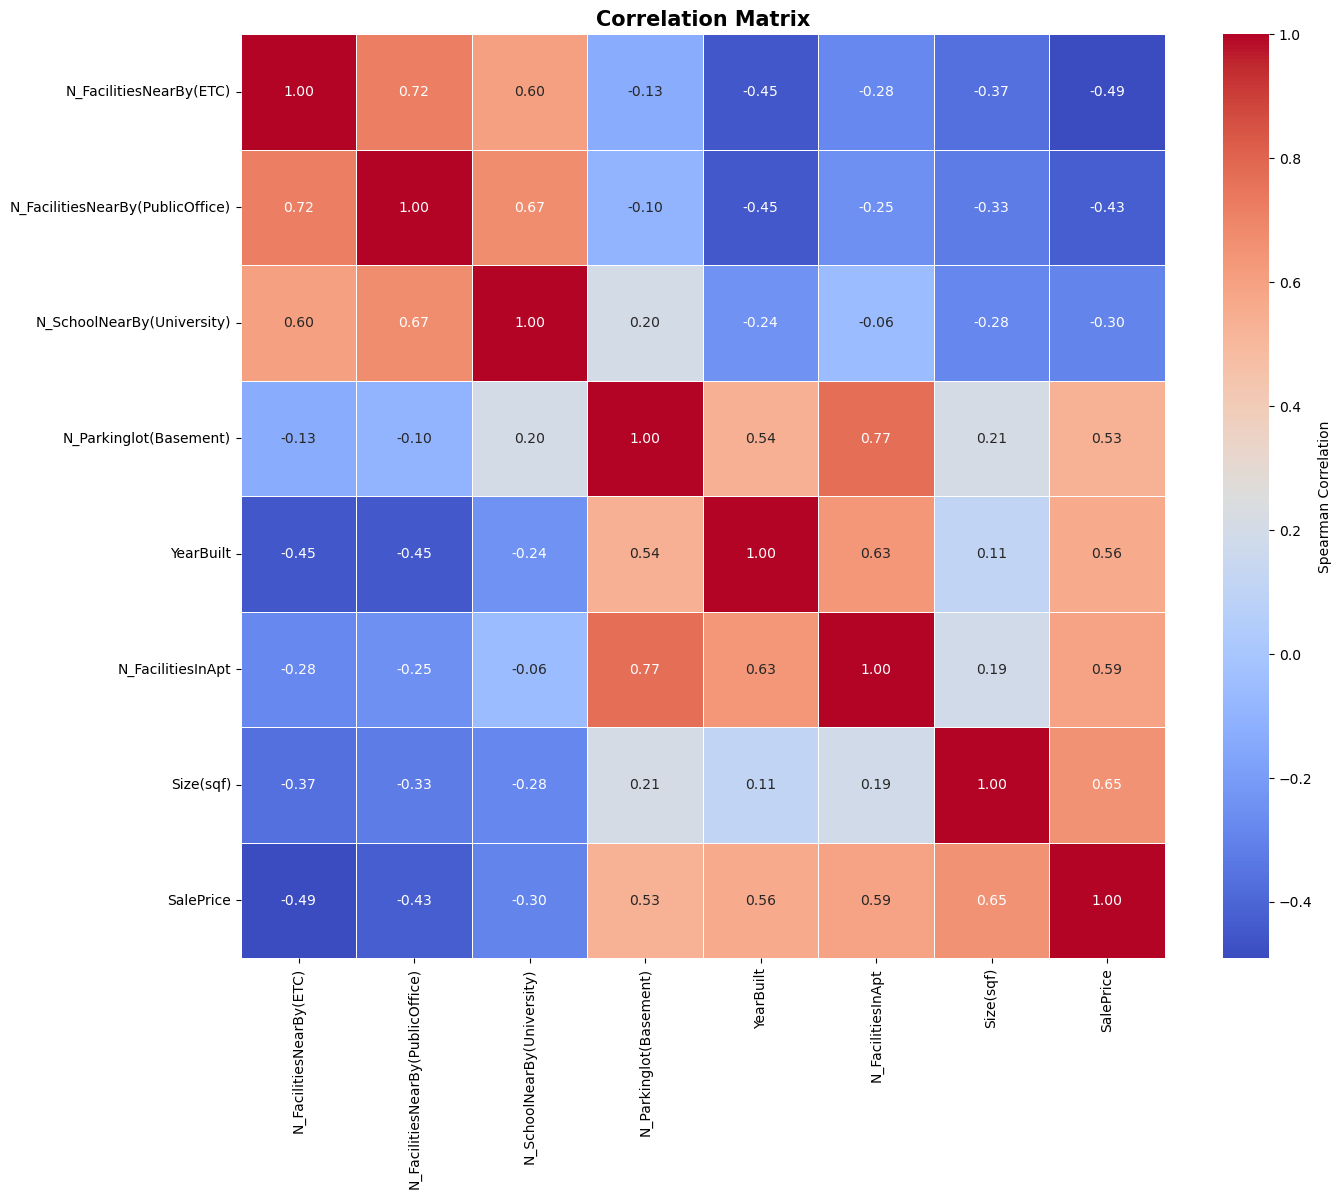

In [15]:
plt.figure(figsize=(15, 12))
corr = df_corr.corr(method='spearman')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=.5,
            cbar_kws={'label': 'Spearman Correlation'}, annot_kws={'size': 10}, xticklabels=corr.columns, yticklabels=corr.columns)

plt.title('Correlation Matrix', size=15, weight='bold')

Correlations with SalePrice

1. **SalePrice and N_FacilitiesNearBy(ETC)**: 
   - Moderate negative correlation (-0.49). 
   - Properties with more nearby facilities might have lower sale prices, possibly due to oversupply or less desirable areas.

2. **SalePrice and N_FacilitiesNearBy(PublicOffice)**: 
   - Moderate negative correlation (-0.43). 
   - More public offices nearby could correlate with lower sale prices, possibly due to lower demand in certain areas.

3. **SalePrice and N_SchoolNearBy(University)**: 
   - Moderate negative correlation (-0.30).
   - Proximity to universities may slightly reduce sale prices, potentially due to higher student occupancy or lower-value locations.

4. **SalePrice and N_Parkinglot(Basement)**: 
   - Moderate positive correlation (0.53).
   - Properties with more parking spaces tend to have higher sale prices, reflecting added value for convenience.

5. **SalePrice and YearBuilt**: 
   - Moderate positive correlation (0.56).
   - Newer buildings tend to have higher sale prices, likely due to modern amenities and construction quality.

6. **SalePrice and N_FacilitiesInApt**: 
   - Strong positive correlation (0.59).
   - Apartments with more facilities inside tend to have higher sale prices, as added amenities increase the value.

7. **SalePrice and Size(sqf)**: 
   - Strong positive correlation (0.65).
   - Larger apartments tend to have higher sale prices, as space is a key determinant of value.


## Price Trend
Since the goal is to **predict the apartment price**, the EDA process will prioritize exploring **how price interacts with other features**. 

In [16]:
import scipy.stats as stats

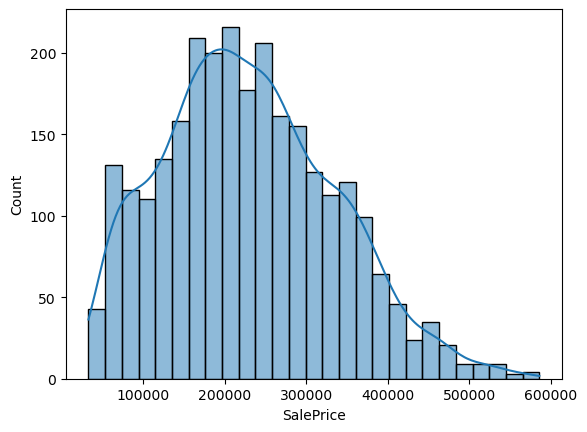

Shapiro-Wilk Test: Stat=0.9829, p-value=0.0000
The feature 'SalePrice' is **NOT** normally distributed.
Skewness: 0.3861, Type: right-skewed


In [17]:
sns.histplot(df, x='SalePrice', kde=True)
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(df['SalePrice'])
if shapiro_p < 0.05:
    print(f"Shapiro-Wilk Test: Stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
    print("The feature 'SalePrice' is **NOT** normally distributed.")
else:
    print(f"Shapiro-Wilk Test: Stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
    print("The feature 'SalePrice' is normally distributed.")

sale_price_skewness = df['SalePrice'].skew()

# Determine skewness type
if sale_price_skewness > 0:
    skew_type = "right-skewed"
elif sale_price_skewness < 0:
    skew_type = "left-skewed"
else:
    skew_type = "not skewed"

print(f"Skewness: {sale_price_skewness:.4f}, Type: {skew_type}")

Since the SalePrice data is right-skewed and not normally distributed, the median will be used to analyze price interactions, as it is not affected by outliers and provides a more accurate representation of the typical price. 

In [18]:
df.head(1)

,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice
0,terraced,0-5min,Kyungbuk_uni_hospital,0.0,3.0,2.0,1270.0,2007,10,1387,346017


### Price and Numerical Columns

In [19]:
features = [
    'N_FacilitiesNearBy(ETC)', 
    'N_FacilitiesNearBy(PublicOffice)', 
    'N_SchoolNearBy(University)', 
    'N_Parkinglot(Basement)', 
    'YearBuilt', 
    'N_FacilitiesInApt', 
    'Size(sqf)'
]

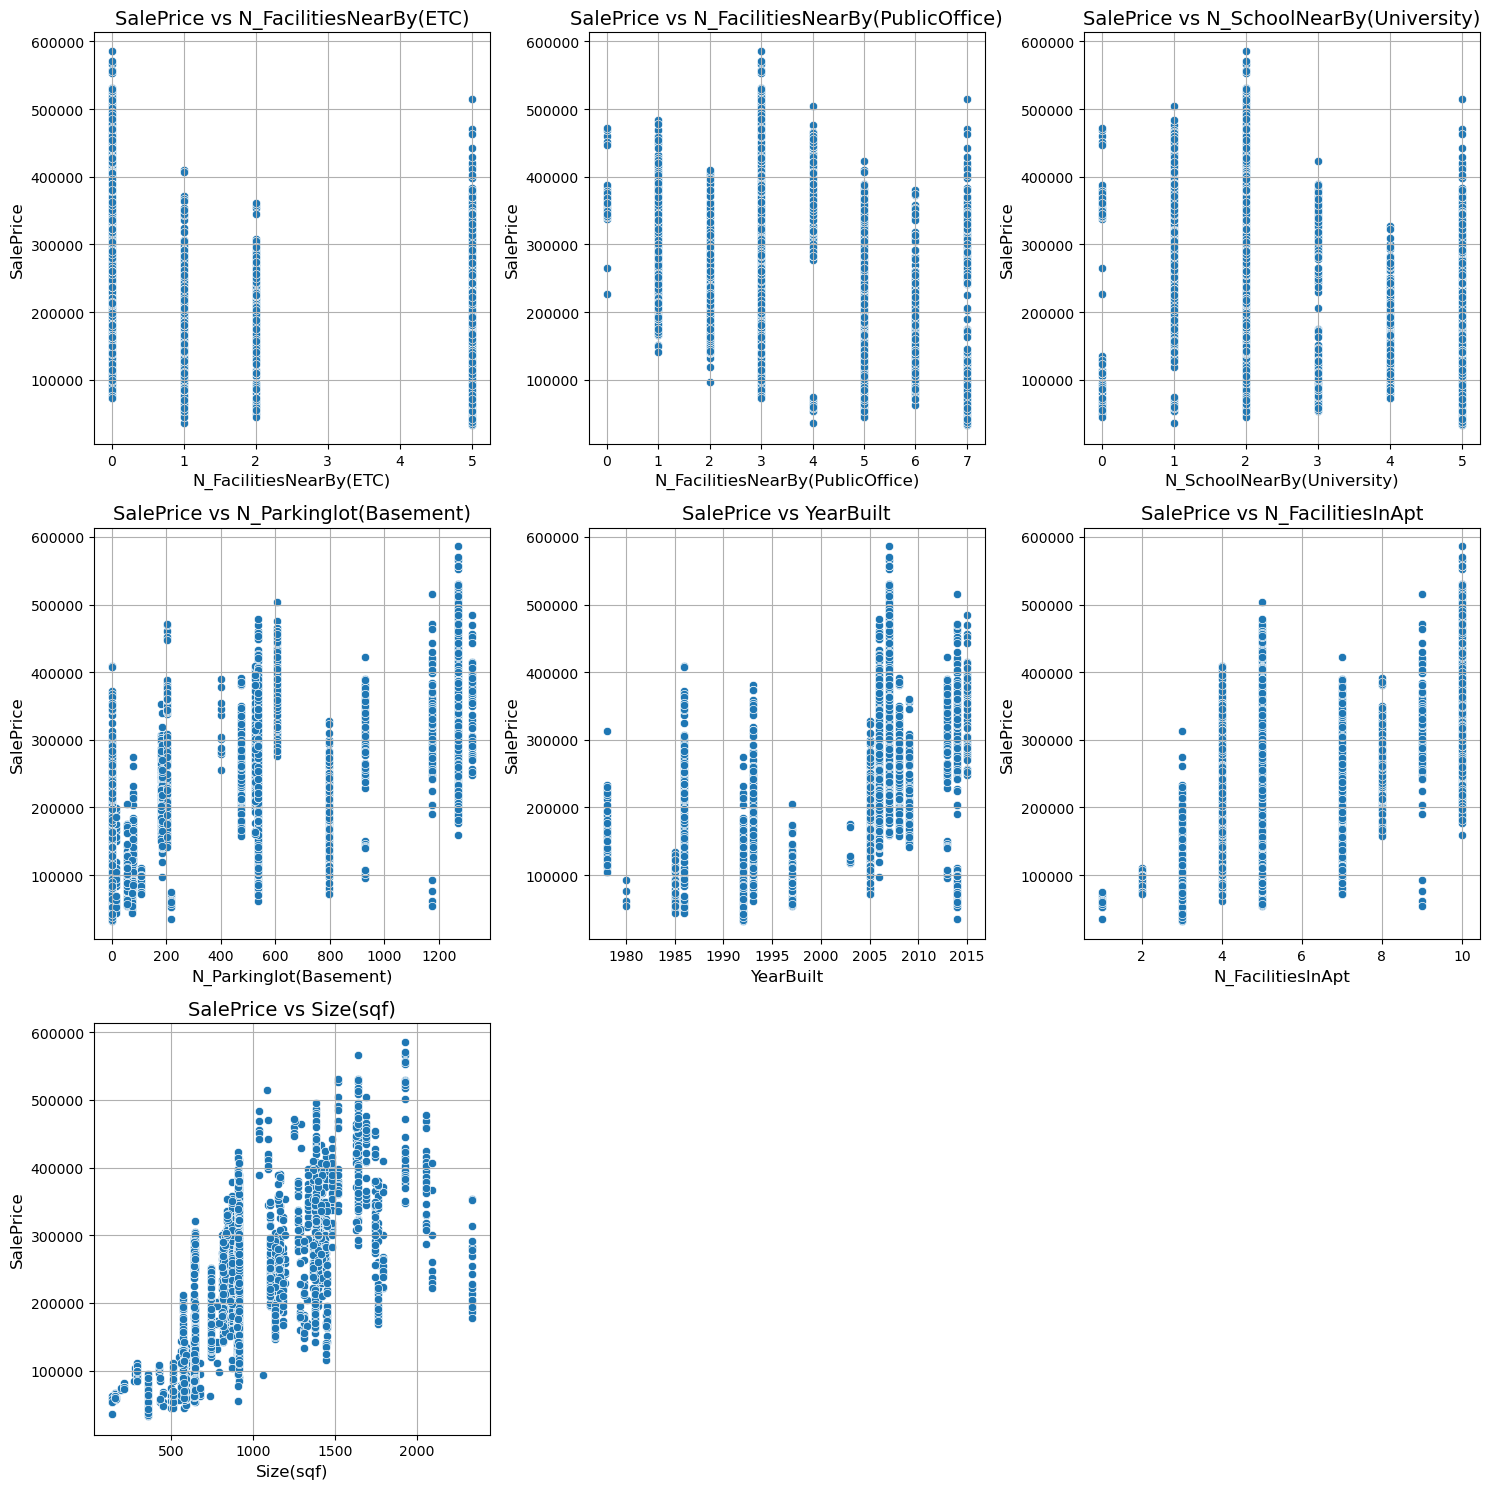

In [20]:
num_features = len(features)
cols = 3  # Number of columns for subplots (adjust as necessary)
rows = math.ceil(num_features / cols)  # Calculate required rows

# Create the figure and axes for subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Loop through each feature and create a scatter plot
for i, feature in enumerate(features):
    sns.scatterplot(data=df, x=feature, y='SalePrice', ax=axes[i])
    axes[i].set_title(f'SalePrice vs {feature}', fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('SalePrice', fontsize=12)
    axes[i].grid(True)
# Hide any unused subplots (in case the number of features isn't a perfect multiple of cols)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')



# Adjust layout to ensure the plots fit neatly
plt.tight_layout()

# Display the plot
plt.show()


1. **SalePrice vs N_FacilitiesNearBy(ETC)**:
   - No clear trend observed, but **SalePrice** tends to be concentrated in the **100,000 to 300,000 won** range for properties with varying numbers of nearby facilities (1 to 5).

2. **SalePrice vs N_FacilitiesNearBy(PublicOffice)**:
   - Similar to the previous plot, there is no significant upward or downward trend with the number of nearby public office facilities, indicating other factors might be more influential.

3. **SalePrice vs N_SchoolNearBy(University)**:
   - Slight **increase in SalePrice** for properties with more universities nearby, especially for those with 1-3 universities in the vicinity, showing a mild positive correlation.

4. **SalePrice vs N_Parkinglot(Basement)**:
   - No distinct pattern, but properties with **fewer parking spaces or none** tend to have lower prices, whereas properties with more parking spaces show wider price distribution.

5. **SalePrice vs YearBuilt**:
   - A **clear upward trend** is observed for newer properties built after 2000, especially from the **2010s onward**, indicating that newer properties tend to have higher prices.

6. **SalePrice vs N_FacilitiesInApt**:
   - **SalePrice increases** with the number of facilities in the apartment, particularly for those with more than 5 facilities, signaling that well-equipped apartments tend to have higher prices.

7. **SalePrice vs Size(sqf)**:
   - A **positive correlation** between apartment **size** and **SalePrice** is evident, with larger apartments generally having higher prices, especially for apartments above **1,000 sqft**.


### Price and Categorical value

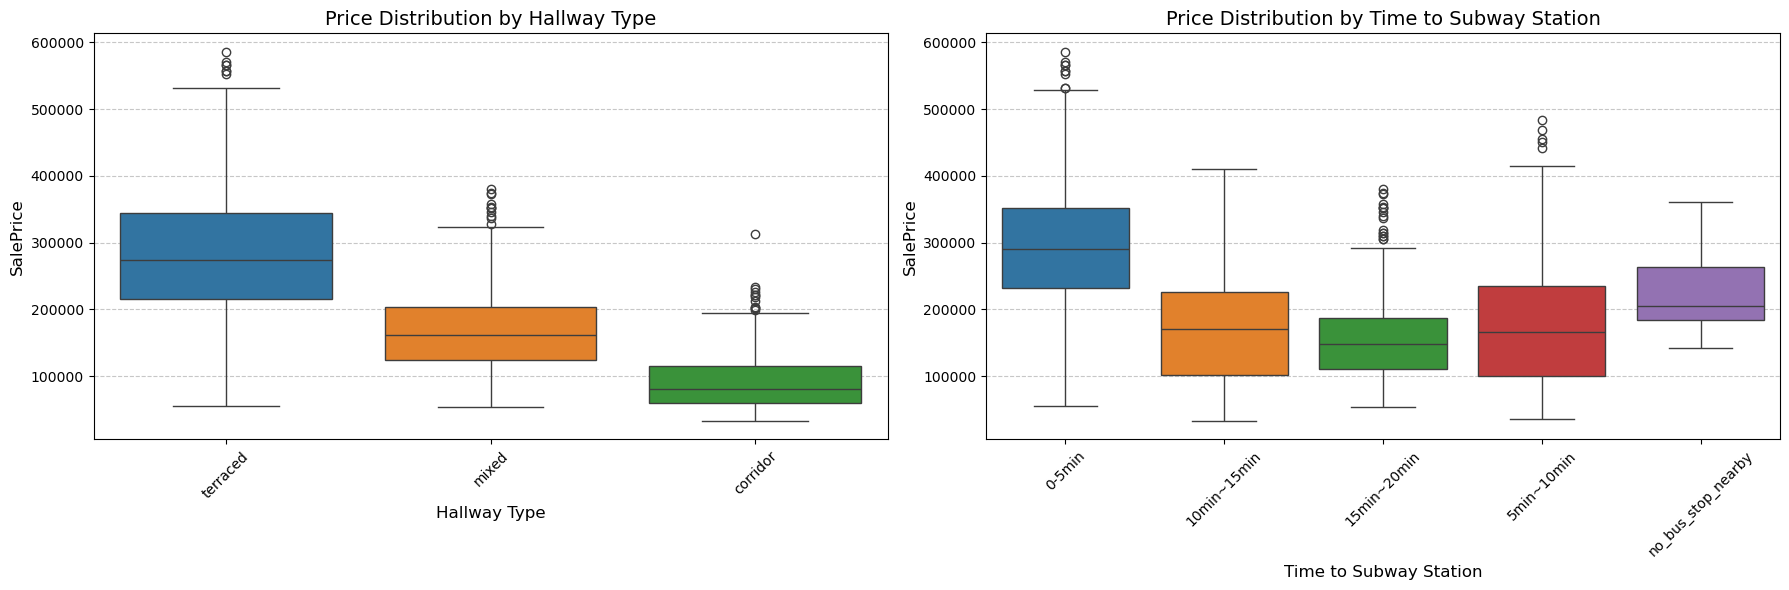

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot the first boxplot for HallwayType vs SalePrice
sns.boxplot(x='HallwayType', y='SalePrice', data=df, hue='HallwayType', ax=axes[0])
axes[0].set_title('Price Distribution by Hallway Type', fontsize=14)
axes[0].set_xlabel('Hallway Type', fontsize=12)
axes[0].set_ylabel('SalePrice', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability

# Plot the second boxplot for TimeToSubway vs SalePrice
sns.boxplot(x='TimeToSubway', y='SalePrice', data=df, hue='TimeToSubway', ax=axes[1])
axes[1].set_title('Price Distribution by Time to Subway Station', fontsize=14)
axes[1].set_xlabel('Time to Subway Station', fontsize=12)
axes[1].set_ylabel('SalePrice', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability

# Adjust the layout to prevent overlap and ensure tight spacing
plt.tight_layout()

# Display the plots
plt.show()


1. **Price Distribution by Hallway Type**:
   - **Terraced** apartments have the highest median price with a wider range, indicating higher values.
   - **Mixed** apartments show moderate median prices with some higher outliers.
   - **Corridor** apartments have the lowest median price, with a consistent range and a few high-price outliers.

2. **Price Distribution by Time to Subway Station**:
   - **0-5 minutes** from the subway have the highest median price and a wide range, indicating high demand.
   - **10-15 minutes** show moderate prices, with smaller variation.
   - **15-20 minutes** show lower median prices with a broader range.
   - **5-10 minutes** is similar to the 15-20 minute group.
   - **No bus stop nearby** shows the lowest median price, indicating lower demand.


### Price and YearBuilt by HallwayType

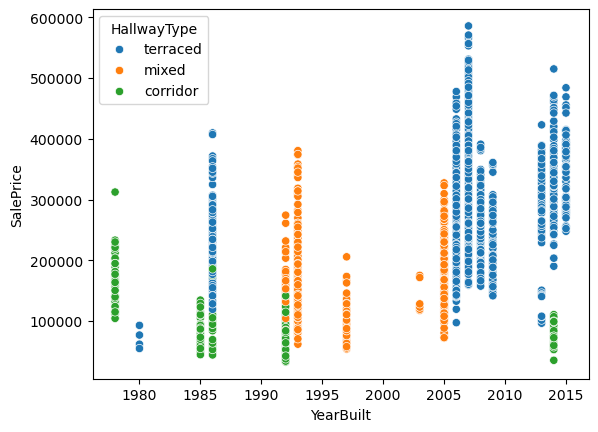

In [22]:
sns.scatterplot(df, x='YearBuilt', y = 'SalePrice', hue='HallwayType')
plt.show()

In [23]:
# 1. Hypothesis test for HallwayType and SalePrice (Kruskal_wallis test)
# Null hypothesis (H0): There is no significant difference in SalePrice among different HallwayTypes
# Alternative hypothesis (H1): There is a significant difference in SalePrice among different HallwayTypes

grouped = [df['SalePrice'][df['HallwayType'] == hallway_type] for hallway_type in df['HallwayType'].unique()]
f_stat, p_value_hallway = stats.kruskal(*grouped)

if p_value_hallway < 0.05:
    print(f"Kruskal-Wallis Test for HallwayType and SalePrice: p-value = {p_value_hallway:.4f}. Reject H0, there is a significant difference.")
else:
    print(f"Kruskal-Wallis Test for HallwayType and SalePrice: p-value = {p_value_hallway:.4f}. Fail to reject H0, no significant difference.")


Kruskal-Wallis Test for HallwayType and SalePrice: p-value = 0.0000. Reject H0, there is a significant difference.


In [24]:
# 2. Hypothesis test for YearBuilt and SalePrice (Pearson correlation test)
# Null hypothesis (H0): There is no linear relationship between YearBuilt and SalePrice
# Alternative hypothesis (H1): There is a linear relationship between YearBuilt and SalePrice

correlation_stat, p_value_yearbuilt = stats.spearmanr(df['YearBuilt'], df['SalePrice'])
if p_value_yearbuilt < 0.05:
    print(f"Spearman Correlation Test for YearBuilt and SalePrice: p-value = {p_value_yearbuilt:.4f}. Reject H0, there is a significant linear relationship.")
else:
    print(f"Spearman Correlation Test for YearBuilt and SalePrice: p-value = {p_value_yearbuilt:.4f}. Fail to reject H0, no significant linear relationship.")

Spearman Correlation Test for YearBuilt and SalePrice: p-value = 0.0000. Reject H0, there is a significant linear relationship.


The scatter plot and hypothesis testing shows that terraced apartments (blue) from the 1980s and 1990s have consistent prices, ranging from 100,000 to 300,000 won. Mixed (orange) and corridor (green) apartments, more common in the 2000s and 2010s, show greater price variability, especially in the range of 200,000 to 500,000 won. Prices for newer apartments (2005-2015) with mixed or corridor hallways tend to be higher. Overall, HallwayType and YearBuilt strongly influence SalePrice, with modern designs leading to higher and more variable prices. 

### Price and Subway Station by Hallway Type

In [25]:
pivot_data = df.pivot_table(index='SubwayStation', columns='HallwayType', values='SalePrice', aggfunc='median', fill_value=0)
pivot_data

HallwayType,corridor,mixed,terraced
SubwayStation,,,
Bangoge,0.0,179867.0,0.0
Banwoldang,98938.0,0.0,314159.0
Chil-sung-market,0.0,92920.0,0.0
Daegu,73451.0,0.0,300884.0
Kyungbuk_uni_hospital,162388.5,0.0,255752.0
Myung-duk,69247.5,157964.0,274336.0
Sin-nam,87610.0,0.0,260176.0
no_subway_nearby,58849.5,0.0,265021.5


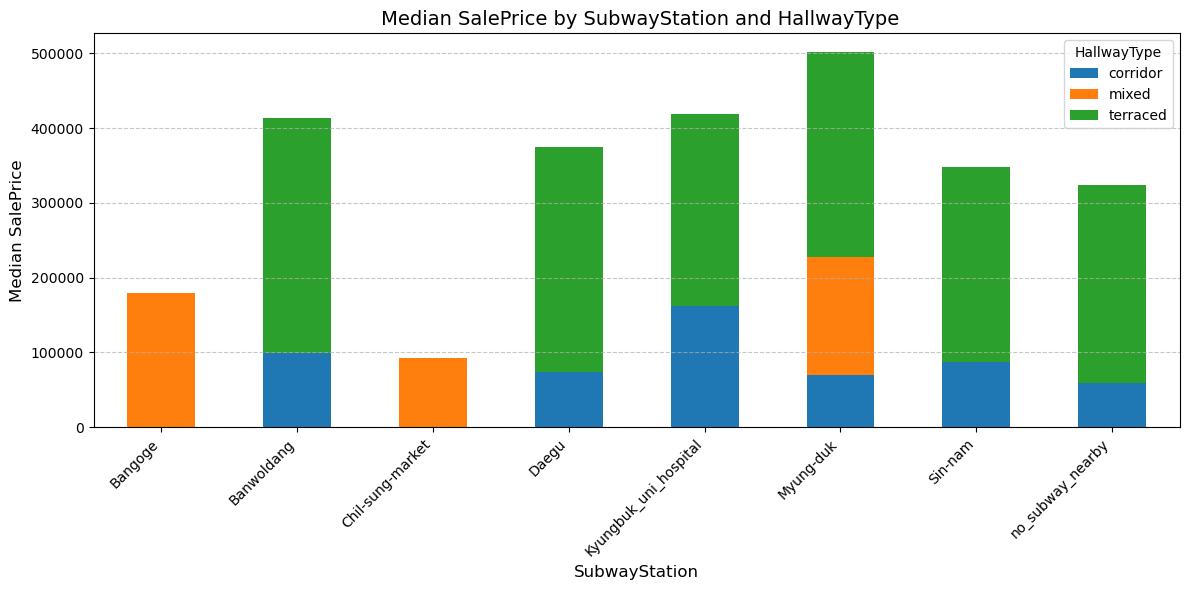

In [26]:
# Plotting the stacked bar plot
ax = pivot_data.plot(kind='bar', stacked=True, figsize=(12, 6))

# Adding titles and labels
plt.title(' Median SalePrice by SubwayStation and HallwayType', fontsize=14)
plt.xlabel('SubwayStation', fontsize=12)
plt.ylabel('Median SalePrice', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

The stacked bar plot shows the median SalePrice for each SubwayStation and breaks it down by HallwayType. Terraced apartments (green) dominate in most stations, particularly in Myung-duk and Kyungbuk_uni_hospital, where the median price is significantly higher. Mixed apartments (orange) show moderate prices, with Banwoldang having a noticeable presence. Corridor apartments (blue) contribute less to the overall price, with the least influence in Chi-sung-market. The plot highlights that SubwayStation and HallwayType both influence the SalePrice, with terraced apartments generally having higher values.

# Modelling

## Defining X and y

In [27]:
# X
X = df.drop(columns='SalePrice')
X

,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf)
0,terraced,0-5min,Kyungbuk_uni_hospital,0.0,3.0,2.0,1270.0,2007,10,1387
1,terraced,10min~15min,Kyungbuk_uni_hospital,1.0,5.0,1.0,0.0,1986,4,914
2,mixed,15min~20min,Chil-sung-market,1.0,7.0,3.0,56.0,1997,5,558
3,mixed,5min~10min,Bangoge,5.0,5.0,4.0,798.0,2005,7,914
4,terraced,0-5min,Sin-nam,0.0,1.0,2.0,536.0,2006,5,1743
...,...,...,...,...,...,...,...,...,...,...
4116,terraced,0-5min,Sin-nam,0.0,1.0,2.0,536.0,2006,5,818
4117,mixed,15min~20min,Myung-duk,5.0,6.0,5.0,536.0,1993,4,1761
4118,terraced,0-5min,Sin-nam,0.0,3.0,2.0,475.0,2008,8,914
4119,mixed,15min~20min,Myung-duk,5.0,6.0,5.0,536.0,1993,4,1451


In [28]:
y = df['SalePrice']
y

0       346017
1       150442
2       61946 
3       165486
4       311504
         ...  
4116    290265
4117    345132
4118    323008
4119    242477
4121    73451 
Name: SalePrice, Length: 2701, dtype: int64

In [29]:
# Splitting (80 train : 20 test)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,
                                                test_size= 0.2,
                                                random_state= 0)

## PreProcess

- OneHotEncoder = 'TimeToSubway', 'SubwayStation'
- OrdinalEncoder = 'HallwayType'

- RobustScaler = 'N_FacilitiesNearBy(ETC)', 'N_FacilitiesNearBy(PublicOffice)',
       'N_SchoolNearBy(University)', 'N_Parkinglot(Basement)', 'YearBuilt',
       'N_FacilitiesInApt', 'Size(sqf)'

In [30]:
df_unique

,0,unqiue
0,HallwayType,"[terraced, mixed, corridor]"
1,TimeToSubway,"[0-5min, 10min~15min, 15min~20min, 5min~10min, no_bus_stop_nearby]"
2,SubwayStation,"[Kyungbuk_uni_hospital, Chil-sung-market, Bangoge, Sin-nam, Banwoldang, no_subway_nearby, Myung-duk, Daegu]"
3,N_FacilitiesNearBy(ETC),"[0.0, 1.0, 5.0, 2.0]"
4,N_FacilitiesNearBy(PublicOffice),"[3.0, 5.0, 7.0, 1.0, 4.0, 2.0, 6.0, 0.0]"
5,N_SchoolNearBy(University),"[2.0, 1.0, 3.0, 4.0, 5.0, 0.0]"
6,N_Parkinglot(Basement),"[1270.0, 0.0, 56.0, 798.0, 536.0, 605.0, 203.0, 108.0, 1174.0, 930.0, 475.0, 184.0, 400.0, 218.0, 1321.0, 524.0, 76.0, 79.0, 181.0, 18.0]"
7,YearBuilt,"[2007, 1986, 1997, 2005, 2006, 2009, 2014, 1993, 2013, 2008, 2015, 1978, 1985, 1992, 2003, 1980]"
8,N_FacilitiesInApt,"[10, 4, 5, 7, 2, 9, 8, 1, 3]"
9,Size(sqf),"[1387, 914, 558, 1743, 1334, 572, 910, 288, 1131, 843, 1160, 644, 829, 743, 868, 1629, 1690, 1273, 1483, 156, 1412, 1394, 903, 676, 355, 1419, 640, 1184, 1167, 135, 818, 206, 1643, 907, 1377, 2337, 1252, 451, 587, 811, 2056, 508, 576, 1366, 1103, 426, 281, 1327, 1092, 857, 1928, 1149, 1088, 1288, 1761, 1437, 1291, 2092, 636, 814, 871, 1519, 1444, 1451, 1448, 1313, 1256, 1796, 1192, 1035, 846, 273, 277, 779, 498, 736, 138, 430, 213, 163, 1369, 192, 547, 839, 160, 793, 1085, 1060, 832]"


In [31]:
encode_map = [
    {
        'col': 'HallwaType', 
        'mapping': {
            'corridor': 1,
            'mixed': 2,
            'terraced': 3
        }
    }
    
    
]

In [32]:
ordinal_scaler = Pipeline(
    [('ordinal',OrdinalEncoder(encode_map)),
    ('robust', RobustScaler())]
)

In [33]:
transformer = ColumnTransformer(
    [('onehot', OneHotEncoder(), ['TimeToSubway', 'SubwayStation']),
     ('ordicla', ordinal_scaler, ['HallwayType']),
     ('robust',RobustScaler(), ['N_FacilitiesNearBy(ETC)', 'N_FacilitiesNearBy(PublicOffice)',
       'N_SchoolNearBy(University)', 'N_Parkinglot(Basement)', 'YearBuilt',
       'N_FacilitiesInApt', 'Size(sqf)'])],

     remainder='passthrough'
)

transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehot', OneHotEncoder(),
                                 ['TimeToSubway', 'SubwayStation']),
                                ('ordicla',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder(verbose=[{'col': 'HallwaType',
                                                                           'mapping': {'corridor': 1,
                                                                                       'mixed': 2,
                                                                                       'terraced': 3}}])),
                                                 ('robust', RobustScaler())]),
                                 ['HallwayType']),
                                ('robust', RobustScaler(),
                                 ['N_FacilitiesNearBy(ETC)',
                                  'N_FacilitiesNearBy(PublicOffice)',
                                  'N_SchoolNearBy(University)',
                                  'N_Parkinglot(Basement)', 'YearBuilt',
                                  'N_FacilitiesInApt', 'Size(sqf)'])])

## Finding Benchmark (CV)

In [34]:
from sklearn.model_selection import KFold
from sklearn.metrics import get_scorer_names
from sklearn.model_selection import cross_validate

In [35]:
get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'max_error',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 'recall_macro',
 'recall_micro',
 '

In [36]:
linear = LinearRegression()
ridge = Ridge(random_state=0)
lasso = Lasso(random_state=0)
knn = KNeighborsRegressor()
tree = DecisionTreeRegressor(random_state=0)
xgb = XGBRegressor()
gradient = GradientBoostingRegressor(random_state=0)
randomforest = RandomForestRegressor()


In [37]:
# model
list_model = [linear, ridge, lasso, knn, tree,  gradient, xgb, randomforest]
list_model_name = ['Linear Regression', 'Ridge', 'Lasso', 'KNN Regressor', 'Decision Tree Regressor',  'Gradient Boost Regressor', 'XGB Regressor', 'Random Forest']

# list scorer
list_scorer = [
        'neg_mean_absolute_error',
        'neg_mean_absolute_percentage_error',
        'neg_root_mean_squared_error',
        'r2'
       
    ]
# list kosong untuk menampung score
list_mean_rmse = []
list_std_rmse = []

list_mean_mae = []
list_std_mae = []
    
list_mean_mape = []
list_std_mape = []

list_mean_mse = []
list_std_mse = []

list_mean_r2 = []
list_std_r2 = []

list_kosong = []

# looping
for i in list_model:
    # pipeline
    pipe_prep_model = Pipeline([
        ('preprocessing', transformer),
        ('model', i)
    ])
    
    # cross validate
    # untuk melakukan cross validation menggunakan beberapa metrics evaluation
    crossval = cross_validate(estimator = pipe_prep_model,
                    X = Xtrain,
                    y = ytrain,
                    cv = 5,
                    n_jobs = -1,
                    scoring = list_scorer)
    
    # rmse
    list_kosong.append(crossval)
    
    list_mean_rmse.append(crossval['test_neg_root_mean_squared_error'].mean())
    list_std_rmse.append(crossval['test_neg_root_mean_squared_error'].std())
    
    # mae
    list_mean_mae.append(crossval['test_neg_mean_absolute_error'].mean())
    list_std_mae.append(crossval['test_neg_mean_absolute_error'].std())
    
    # mape
    list_mean_mape.append(crossval['test_neg_mean_absolute_percentage_error'].mean())
    list_std_mape.append(crossval['test_neg_mean_absolute_percentage_error'].std())

    # r2
    list_mean_r2.append(crossval['test_r2'].mean())
    list_std_r2.append(crossval['test_r2'].std())

In [38]:
df_score = pd.DataFrame()
df_score['Model'] = list_model_name

df_score['Mean_RMSE'] = list_mean_rmse
df_score['Std_RMSE'] = list_std_rmse

df_score['Mean_MAE'] = list_mean_mae
df_score['Std_MAE'] = list_std_mae

df_score['Mean_MAPE'] = list_mean_mape
df_score['Std_MAPE'] = list_std_mape

df_score['Mean_R2'] = list_mean_r2
df_score['Std_R2'] = list_std_r2 

df_score

,Model,Mean_RMSE,Std_RMSE,Mean_MAE,Std_MAE,Mean_MAPE,Std_MAPE,Mean_R2,Std_R2
0,Linear Regression,-51800.660879,2071.236839,-41977.206944,1561.547822,-0.217507,0.013570,0.753934,0.019591
1,Ridge,-51766.304812,2079.593021,-41958.460905,1564.382045,-0.216448,0.013040,0.754266,0.019558
2,Lasso,-51763.804014,2089.447801,-41920.753537,1570.240916,-0.216260,0.013060,0.754285,0.019655
3,KNN Regressor,-49980.435765,2339.019281,-39719.216667,1674.247611,-0.203723,0.014233,0.770678,0.022688
4,Decision Tree Regressor,-46710.625523,2030.864189,-37659.339352,1051.893623,-0.194767,0.009949,0.799671,0.019675
5,Gradient Boost Regressor,-46320.292745,2026.451571,-37688.030058,1130.359569,-0.194989,0.009364,0.802922,0.020273
6,XGB Regressor,-46489.754677,1891.655138,-37588.285019,1044.914030,-0.194199,0.008940,0.801496,0.019757
7,Random Forest,-46528.594791,1964.770858,-37617.521241,1135.733660,-0.194362,0.009462,0.801140,0.020293


To determine the best model for predicting apartment prices based on MAE, RMSE, and R², let's focus on comparing these metrics across the models you provided.

- Lowest MAE (Mean Absolute Error): This represents the smallest average error in price predictions.
- Lowest RMSE (Root Mean Squared Error): This accounts for large errors more heavily and should be minimized.
- Highest R²: This indicates the percentage of variance explained by the model, and the closer to 1 it is, the better the model explains the price variation.

Considering this metrics, we have 2 best candidates for benchmark: 
- GradientBoost:

    - Mean R²: 0.8045 (highest)    
    - Mean MAE: 37688.53
    - Mean RMSE: 46322.54
- XGB (XGBoost):

    - Mean R²: 0.8015
    - Mean MAE: 37588.03
    - Mean RMSE: 46448.24

# Predicting using benchmark models

In [39]:
list_kosong= []
score_rmse = []
score_mae = []
score_mape = []
score_r2 = []


benchmark_model = [xgb, gradient]

for model in benchmark_model:
    model_pipeline = Pipeline([
            ('preprocess', transformer),
            ('model', model)
        ])
    
    model_pipeline.fit(Xtrain, ytrain)
    y_pred = model_pipeline.predict(Xtest)
    score_rmse.append(np.sqrt(mean_squared_error(ytest, y_pred)))
    score_mae.append(mean_absolute_error(ytest, y_pred))
    score_mape.append(mean_absolute_percentage_error(ytest, y_pred))
    score_r2.append(r2_score(ytest, y_pred))

In [40]:
df_score = pd.DataFrame()
df_score['Model'] = ['XGB', 'Gradient'] # benchmark_model = [xgb, gradient]

df_score['RMSE'] = score_rmse
df_score['MAE'] = score_mae
df_score['MAPE'] = score_mape
df_score['R2'] = score_r2


df_score

,Model,RMSE,MAE,MAPE,R2
0,XGB,46820.813084,37328.297864,0.184079,0.807049
1,Gradient,46305.213031,36832.121642,0.180459,0.811275


Testing the prediction of benchmark model, 
- Accuracy (R²): GradientBoost explains a slightly larger portion of the price variation compared to XGB, making it a bit more accurate in predicting apartment prices.

- Error Size (RMSE & MAE): GradientBoost has smaller prediction errors (both RMSE and MAE) than XGB, meaning it makes more accurate price predictions.

- Relative Error (MAPE): Both models have very similar relative errors, so they perform almost the same when considering percentage errors.

**GradientBoost is the better model**, as it provides more accurate predictions with smaller errors compared to XGB. We will proceed to tune GradientBoost as it is the better model

## Hyperparametric Tuning (GradientBoost)

Gradient boost is an ensemble machine learning algorithm that builds a predictive model in a sequential, iterative manner by combining multiple weak learners (typically decision trees) to create a strong learner. Gradient Boosting works in iterations (or stages), where each iteration corrects the errors made by the previous model. 

In this context:
Imagine you’re trying to guess the price of an apartment, but you’re not very good at it at first. You start by making a rough guess, like the average price of all apartments. But your guess isn’t perfect—it’s too high for some apartments and too low for others.
Now, you decide to improve your guess step by step. Here’s how:


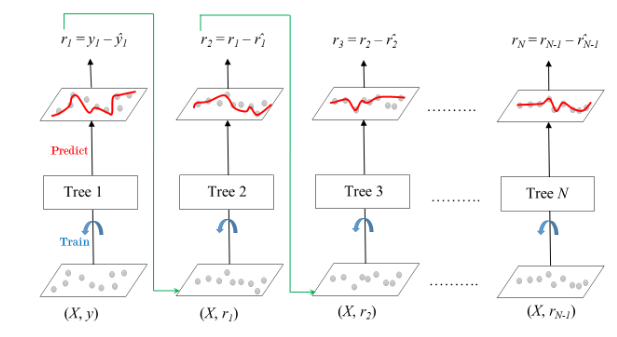
1. Find Your Mistakes: You look at how far off your guess was for each apartment (these are called "errors" or "residuals"). For example, if you guess 200,000 220,000, your mistake is 20,000.
2. Learn from Mistakes: You try to learn a pattern from these mistakes. Maybe you notice that apartments near schools tend to be underpriced in your guess. So, you adjust your guess to account for this pattern.
3. Update Your Guess: You add this new pattern (scaled down a bit so you don’t overcorrect) to your original guess. Now, your guess is a little better.
4. Repeat: You keep doing this over and over—finding mistakes, learning patterns, and updating your guess. Each time, your guess gets a little better because you’re fixing the errors from the previous step.
5. Final Guess: After many rounds of this, you end up with a really good guess that’s close to the actual price of the apartment.

Gradient Boosting is like a super-smart way of learning from mistakes. It combines many small improvements to make a very accurate prediction. 



Parameters Tuned

1. **`n_estimators`**: 
   - **Definition**: Number of boosting stages (trees).
   - **Effect**: 
     - **Higher values** lead to more trees, improving model fit but may cause **overfitting**.
     - **Lower values** reduce model complexity, possibly causing **underfitting**.

2. **`learning_rate`**: 
   - **Definition**: Step size to correct each tree's prediction.
   - **Effect**:
     - **Lower values** result in slower learning, requiring more trees to converge, but can prevent **overfitting**.
     - **Higher values** speed up learning but may cause **overfitting** faster.

3. **`max_depth`**: 
   - **Definition**: Maximum depth of each decision tree.
   - **Effect**:
     - **Larger values** allow deeper trees, capturing more complex patterns but may lead to **overfitting**.
     - **Smaller values** produce **simpler trees**, but may lead to **underfitting** if set too low.

4. **`min_samples_split`**: 
   - **Definition**: Minimum number of samples required to split an internal node.
   - **Effect**:
     - **Higher values** lead to **simpler trees** with fewer splits, preventing overfitting but might cause underfitting.
     - **Lower values** allow for more splits, leading to deeper trees that may **overfit**.

5. **`min_samples_leaf`**: 
   - **Definition**: Minimum number of samples required to be at a leaf node.
   - **Effect**:
     - **Higher values** lead to **broader leaves** with fewer splits, promoting a **regularized model**.
     - **Lower values** make leaves more granular, increasing model complexity, which may lead to **overfitting**.


In [41]:
gradient_model = Pipeline([
        ('preprocess', transformer),
        ('model', gradient)
    ])

In [42]:
param_grid = {
    'model__n_estimators': np.arange(100, 451, 50),  # Number of trees: from 50 to 250, step 50
    'model__learning_rate': np.arange(0.0, 2.1, 0.1),  # Learning rate range: from 0.1 to 1.0 with step 0.1
    'model__max_depth': np.arange(3, 11, 1),  # Depth of trees: from 3 to 10
    'model__min_samples_split': np.arange(2, 61, 1),  # Minimum samples to split: from 2 to 10
    'model__min_samples_leaf': np.arange(1, 61, 1)  # Minimum samples in a leaf: from 1 to 10
}

In [43]:
list_scorer

['neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_root_mean_squared_error',
 'r2']

In [44]:
randomsearch = RandomizedSearchCV(
    estimator= gradient_model,
    param_distributions= param_grid,
    cv= 5,
    scoring=list_scorer,
    refit='neg_root_mean_squared_error',
    n_jobs=-1,
    n_iter=50

)

In [45]:
# randomsearch.fit(Xtrain,ytrain)

In [46]:
import joblib

# Save the model after fitting
joblib.dump(randomsearch, 'randsearch_model.pkl')

# Now you can load the model whenever you need it
loaded_model = joblib.load('randsearch_model.pkl')

In [47]:
loaded_model

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('onehot',
                                                                               OneHotEncoder(),
                                                                               ['TimeToSubway',
                                                                                'SubwayStation']),
                                                                              ('ordicla',
                                                                               Pipeline(steps=[('ordinal',
                                                                                                OrdinalEncoder(verbose=[{'col': 'HallwaType',
                                                                                                                         'mapping': {'corridor': 1,
                                                                                                                                     'mixed': 2,
                                                                                                                                     'terraced': 3}}])),
                                                                                               ('robust',
                                                                                                RobustScaler())]),
                                                                               ['Hallwa...
                                        'model__min_samples_split': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52,
       53, 54, 55, 56, 57, 58, 59, 60]),
                                        'model__n_estimators': array([100, 150, 200, 250, 300, 350, 400, 450])},
                   refit='neg_root_mean_squared_error',
                   scoring=['neg_mean_absolute_error',
                            'neg_mean_absolute_percentage_error',
                            'neg_root_mean_squared_error', 'r2'])

In [48]:
loaded_model.fit(Xtrain,ytrain)
y_pred = loaded_model.predict(Xtest) 

# Example: Print the best parameters and model score
print(f"Best Parameters: {loaded_model.best_params_}")
print(f"Best RMSE (neg_root_mean_squared_error): {-loaded_model.best_score_:.5f}")

Best Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 56, 'model__min_samples_leaf': 52, 'model__max_depth': 3, 'model__learning_rate': 0.2}
Best RMSE (neg_root_mean_squared_error): 46323.61847


In [49]:
# model
model_before  = gradient_model

model_before.fit(Xtrain,ytrain)

y_pred_train = model_before.predict(Xtrain)

y_pred_test = model_before.predict(Xtest)
root_mean_squared_error(ytest,y_pred_test)


rmse = root_mean_squared_error(ytest,y_pred_test) # Ensure ytest is defined
mae = mean_absolute_error(ytest,y_pred_test)
r2 = r2_score(ytest,y_pred_test)
mape = mean_absolute_percentage_error(ytest,y_pred_test) * 100  # MAPE in percentage

print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}")

RMSE: 46305.21303
MAE: 36832.12164
R²: 0.81127
MAPE: 18.04587


In [50]:
model_after  = loaded_model.best_estimator_

model_after.fit(Xtrain,ytrain)

y_pred_train = model_after.predict(Xtrain)

y_pred_test = model_after.predict(Xtest)


rmse = root_mean_squared_error(ytest,y_pred_test) # Ensure ytest is defined
mae = mean_absolute_error(ytest,y_pred_test)
r2 = r2_score(ytest,y_pred_test)
mape = mean_absolute_percentage_error(ytest,y_pred_test) * 100  # MAPE in percentage

print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}")

RMSE: 47046.10801
MAE: 37303.15623
R²: 0.80519
MAPE: 18.67856


### Feature Importance

In [51]:
# fit to x train
transformer.fit(Xtrain.copy())

#transform
Xtrain_scaled = transformer.transform(Xtrain)
Xtest_scaled = transformer.transform(Xtest)

In [52]:
feature_list = [list(item[1].get_feature_names_out()) for item in transformer.transformers_]
feature_extracted = [name for item in feature_list for name in item]
feature_extracted

['TimeToSubway_0-5min',
 'TimeToSubway_10min~15min',
 'TimeToSubway_15min~20min',
 'TimeToSubway_5min~10min',
 'TimeToSubway_no_bus_stop_nearby',
 'SubwayStation_Bangoge',
 'SubwayStation_Banwoldang',
 'SubwayStation_Chil-sung-market',
 'SubwayStation_Daegu',
 'SubwayStation_Kyungbuk_uni_hospital',
 'SubwayStation_Myung-duk',
 'SubwayStation_Sin-nam',
 'SubwayStation_no_subway_nearby',
 'HallwayType',
 'N_FacilitiesNearBy(ETC)',
 'N_FacilitiesNearBy(PublicOffice)',
 'N_SchoolNearBy(University)',
 'N_Parkinglot(Basement)',
 'YearBuilt',
 'N_FacilitiesInApt',
 'Size(sqf)']

In [53]:
Xtest_scaled_df = pd.DataFrame(Xtest_scaled)
Xtest_scaled_df.columns = feature_extracted
Xtest_scaled_df

,TimeToSubway_0-5min,TimeToSubway_10min~15min,TimeToSubway_15min~20min,TimeToSubway_5min~10min,TimeToSubway_no_bus_stop_nearby,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,...,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby,HallwayType,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf)
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.2,-1.5,0.0,0.000000,0.000000,0.000000,-0.216981
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.5,0.5,-0.777958,-0.214286,0.000000,-0.007075
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.8,1.0,1.5,0.000000,-0.928571,-0.333333,0.009434
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-0.2,-2.0,-1.0,-0.539708,0.571429,1.666667,0.009434
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.8,0.5,1.0,0.424635,-0.071429,0.666667,-0.797170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,-0.2,-0.5,0.0,1.189627,0.071429,1.666667,1.125000
537,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.2,-1.0,-0.5,-0.539708,0.214286,0.000000,0.000000
538,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.8,0.5,1.0,0.424635,-0.071429,0.666667,-0.393868
539,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.2,-0.5,0.0,-0.098865,0.142857,1.000000,0.009434


In [54]:
Xtrain_scaled_df = pd.DataFrame(Xtrain_scaled)
Xtrain_scaled_df.columns = feature_extracted
Xtrain_scaled_df

,TimeToSubway_0-5min,TimeToSubway_10min~15min,TimeToSubway_15min~20min,TimeToSubway_5min~10min,TimeToSubway_no_bus_stop_nearby,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,...,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby,HallwayType,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf)
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,-0.2,0.5,0.5,0.638574,0.500000,0.666667,0.000000
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.2,-0.5,0.0,-0.098865,0.142857,1.000000,-0.191038
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,-0.2,0.5,0.5,0.638574,0.500000,0.666667,0.000000
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.8,0.5,1.0,0.424635,-0.071429,0.666667,0.009434
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.2,-1.0,-0.5,-0.539708,0.214286,0.000000,0.589623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,-0.2,0.5,0.5,0.638574,0.500000,0.666667,-0.007075
2156,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.8,1.5,1.5,1.034036,0.571429,1.333333,0.000000
2157,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.8,1.0,1.5,0.000000,-0.928571,-0.333333,1.275943
2158,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.8,1.0,1.5,0.000000,-0.928571,-0.333333,-0.627358


In [55]:
df_coef = pd.DataFrame()
df_coef['features'] = feature_extracted
df_coef['importance'] = model_after[-1].feature_importances_
df_coef = df_coef.sort_values('importance', ascending=False).reset_index().drop(columns='index')
df_coef

,features,importance
0,HallwayType,0.423582
1,Size(sqf),0.354702
2,YearBuilt,0.078348
3,N_Parkinglot(Basement),0.053811
4,N_FacilitiesInApt,0.048119
5,N_FacilitiesNearBy(ETC),0.033390
6,N_SchoolNearBy(University),0.002818
7,N_FacilitiesNearBy(PublicOffice),0.002117
8,TimeToSubway_0-5min,0.001237
9,SubwayStation_no_subway_nearby,0.001130


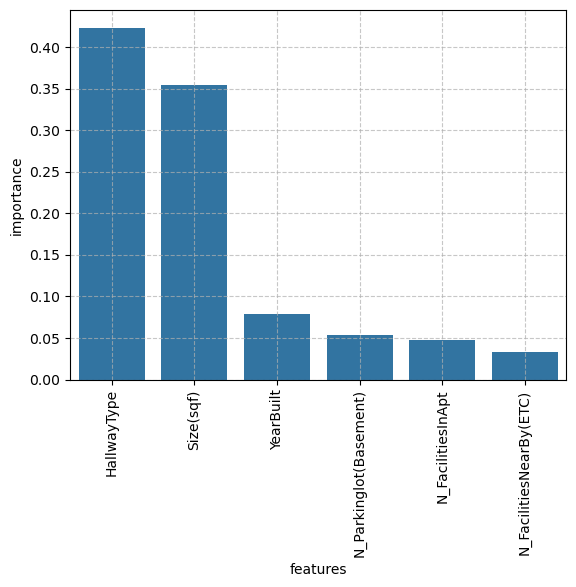

In [56]:
sns.barplot(df_coef.head(6), y='importance', x='features')

plt.xticks(rotation=90)
plt.grid(axis='both', linestyle='--', alpha=0.7)

plt.show()

Looking at the values, we will filter out the features that have importance > 0.006. We will be using the top 6 feature

In [57]:
important_feature = df_coef.head(6)['features'].tolist()

In [58]:

Xtrain_feature_importance= Xtrain_scaled_df[important_feature]
Xtrain_feature_importance

Xtest_feature_importance= Xtest_scaled_df[important_feature]
Xtest_feature_importance


,HallwayType,Size(sqf),YearBuilt,N_Parkinglot(Basement),N_FacilitiesInApt,N_FacilitiesNearBy(ETC)
0,0.0,-0.216981,0.000000,0.000000,0.000000,-0.2
1,1.0,-0.007075,-0.214286,-0.777958,0.000000,0.0
2,1.0,0.009434,-0.928571,0.000000,-0.333333,0.8
3,0.0,0.009434,0.571429,-0.539708,1.666667,-0.2
4,1.0,-0.797170,-0.071429,0.424635,0.666667,0.8
...,...,...,...,...,...,...
536,0.0,1.125000,0.071429,1.189627,1.666667,-0.2
537,0.0,0.000000,0.214286,-0.539708,0.000000,0.2
538,1.0,-0.393868,-0.071429,0.424635,0.666667,0.8
539,0.0,0.009434,0.142857,-0.098865,1.000000,-0.2


# Comparison

In [59]:
gradient_model = Pipeline([
        ('preprocess', transformer),
        ('model', gradient)
    ])

### Control

#### Benchmark

In [60]:
control = pd.DataFrame()
control['model'] = ['Benchmark', 'After Tuning']

In [61]:
control = pd.DataFrame()
control['model'] = ['Benchmark', 'After Tuning']
train_list = []
test_list = []

train_list_r2 = []
test_list_r2 = []


In [62]:
# model

model_before  = gradient_model

model_before.fit(Xtrain,ytrain)

y_pred_train = model_before.predict(Xtrain)

y_pred_test = model_before.predict(Xtest)
root_mean_squared_error(ytest,y_pred_test)


rmse = root_mean_squared_error(ytest,y_pred_test) 
mae = mean_absolute_error(ytest,y_pred_test)
r2 = r2_score(ytest,y_pred_test)
mape = mean_absolute_percentage_error(ytest,y_pred_test) * 100  # MAPE in percentage

print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}")

RMSE: 46305.21303
MAE: 36832.12164
R²: 0.81127
MAPE: 18.04587


In [63]:
test_result = root_mean_squared_error(ytest,y_pred_test)
test_result_r2 = r2_score(ytest,y_pred_test)
test_result_mape = mean_absolute_percentage_error(ytest,y_pred_test)

test_list.append(test_result)
test_list_r2.append(test_result_r2)


In [64]:

train_result = root_mean_squared_error(ytrain,y_pred_train)
train_result_r2 = r2_score(ytrain,y_pred_train)


train_list.append(train_result)
train_list_r2.append(train_result_r2)


#### After tuning

In [65]:
model_after  = loaded_model.best_estimator_

model_after.fit(Xtrain,ytrain)

y_pred_train = model_after.predict(Xtrain)

y_pred_test = model_after.predict(Xtest)


rmse = root_mean_squared_error(ytest,y_pred_test) # Ensure ytest is defined
mae = mean_absolute_error(ytest,y_pred_test)
r2 = r2_score(ytest,y_pred_test)
mape = mean_absolute_percentage_error(ytest,y_pred_test) * 100  # MAPE in percentage

print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}")

RMSE: 47046.10801
MAE: 37303.15623
R²: 0.80519
MAPE: 18.67856


In [66]:
test_result = root_mean_squared_error(ytest,y_pred_test)
test_result_r2 = r2_score(ytest,y_pred_test)


test_list.append(test_result)
test_list_r2.append(test_result_r2)


In [67]:

train_result = root_mean_squared_error(ytrain,y_pred_train)
train_result_r2 = r2_score(ytrain,y_pred_train)


train_list.append(train_result)
train_list_r2.append(train_result_r2)


In [68]:
control['Test RMSE'] = test_list
control['Train RMSE'] = train_list

control['Test R2'] = test_list_r2
control['Train R2'] = train_list_r2

control


,model,Test RMSE,Train RMSE,Test R2,Train R2
0,Benchmark,46305.213031,44576.466993,0.811275,0.818618
1,After Tuning,47046.108011,44455.379719,0.805187,0.819602


The benchmark model, with an RMSE of 46,305.21 and an R² of 0.811, serves as a the best model even after the hyperparametric tuning process. We will continue testing the model with only the important features, we aim to simplify the model, reduce overfitting, and potentially enhance interpretability without significantly compromising performance

### After only using important feature

In [69]:
treatment = control.drop(index=1)
treatment


,model,Test RMSE,Train RMSE,Test R2,Train R2
0,Benchmark,46305.213031,44576.466993,0.811275,0.818618


In [70]:
model_feature_importance  = gradient# using the benchmark model

model_feature_importance.fit(Xtrain_feature_importance,ytrain) # using the previously scaled Xtrain during the feature importantce process

y_pred_train = model_feature_importance.predict(Xtrain_feature_importance)

y_pred_test = model_feature_importance.predict(Xtest_feature_importance)



rmse = root_mean_squared_error(ytest,y_pred_test) # Ensure ytest is defined
mae = mean_absolute_error(ytest,y_pred_test)
r2 = r2_score(ytest,y_pred_test)
mape = mean_absolute_percentage_error(ytest,y_pred_test) * 100  # MAPE in percentage

print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}")

RMSE: 46423.07760
MAE: 36989.67830
R²: 0.81031
MAPE: 18.16235


In [71]:

test_result = root_mean_squared_error(ytest,y_pred_test)
test_result_r2 = r2_score(ytest,y_pred_test)

train_result = root_mean_squared_error(ytrain,y_pred_train)
train_result_r2 = r2_score(ytrain,y_pred_train)

In [72]:
treatment1 = {'model': 'Important Feature only', 
                        'Test RMSE': test_result,
                        'Train RMSE': train_result,
                        'Test R2': test_result_r2,
                        'Train R2': train_result_r2}

treatment = pd.concat([treatment, pd.DataFrame([treatment1])], ignore_index=True)
treatment

,model,Test RMSE,Train RMSE,Test R2,Train R2
0,Benchmark,46305.213031,44576.466993,0.811275,0.818618
1,Important Feature only,46423.077604,44589.567746,0.810313,0.818512


## Using Forward Sequential Feature Selector

In [73]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

In [74]:
list_scorer

['neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_root_mean_squared_error',
 'r2']

In [75]:
X.shape[1]

10

In [76]:
gradient_model = Pipeline([
        ('preprocess', transformer),
        ('model', gradient)
    ])

In [77]:
Xtrain = pd.DataFrame(Xtrain)

In [78]:
Xtrain_scaled_df

,TimeToSubway_0-5min,TimeToSubway_10min~15min,TimeToSubway_15min~20min,TimeToSubway_5min~10min,TimeToSubway_no_bus_stop_nearby,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Chil-sung-market,SubwayStation_Daegu,SubwayStation_Kyungbuk_uni_hospital,...,SubwayStation_Sin-nam,SubwayStation_no_subway_nearby,HallwayType,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf)
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,-0.2,0.5,0.5,0.638574,0.500000,0.666667,0.000000
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.2,-0.5,0.0,-0.098865,0.142857,1.000000,-0.191038
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,-0.2,0.5,0.5,0.638574,0.500000,0.666667,0.000000
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.8,0.5,1.0,0.424635,-0.071429,0.666667,0.009434
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.2,-1.0,-0.5,-0.539708,0.214286,0.000000,0.589623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2155,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,-0.2,0.5,0.5,0.638574,0.500000,0.666667,-0.007075
2156,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.8,1.5,1.5,1.034036,0.571429,1.333333,0.000000
2157,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.8,1.0,1.5,0.000000,-0.928571,-0.333333,1.275943
2158,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.8,1.0,1.5,0.000000,-0.928571,-0.333333,-0.627358


In [79]:
model = gradient

In [80]:

sfs_mlxtend_forward = SFS(
    estimator=model,
    k_features=21,  
    forward=True,  
    verbose=0,  
    cv=5,
    scoring='neg_root_mean_squared_error'
    
)


In [81]:
sfs_mlxtend_forward.fit(Xtrain_scaled_df, ytrain)

SequentialFeatureSelector(estimator=GradientBoostingRegressor(random_state=0),
                          k_features=(21, 21),
                          scoring='neg_root_mean_squared_error')

In [82]:
# score tiap pengurangan jumlah feature
df_back = pd.DataFrame.from_dict(sfs_mlxtend_forward.get_metric_dict()).T

In [83]:
df_back['avg_score'] = df_back['avg_score'].apply(lambda x: -1*x)

In [84]:
# feature terpilih

df_back.sort_values(by= 'avg_score')

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
11,"(1, 3, 5, 6, 9, 10, 15, 16, 17, 18, 20)","[-43606.51680688131, -44518.11590143941, -48495.35570910814, -46380.30202159887, -47560.37308857993]",46112.132706,"(TimeToSubway_10min~15min, TimeToSubway_5min~10min, SubwayStation_Bangoge, SubwayStation_Banwoldang, SubwayStation_Kyungbuk_uni_hospital, SubwayStation_Myung-duk, N_FacilitiesNearBy(PublicOffice), N_SchoolNearBy(University), N_Parkinglot(Basement), YearBuilt, Size(sqf))",2346.708041,1825.818582,912.909291
10,"(1, 3, 5, 6, 9, 15, 16, 17, 18, 20)","[-43606.51680688131, -44518.11590143941, -48495.35570910814, -46380.30202159887, -47560.37308857993]",46112.132706,"(TimeToSubway_10min~15min, TimeToSubway_5min~10min, SubwayStation_Bangoge, SubwayStation_Banwoldang, SubwayStation_Kyungbuk_uni_hospital, N_FacilitiesNearBy(PublicOffice), N_SchoolNearBy(University), N_Parkinglot(Basement), YearBuilt, Size(sqf))",2346.708041,1825.818582,912.909291
14,"(1, 3, 5, 6, 7, 9, 10, 14, 15, 16, 17, 18, 19, 20)","[-43511.061358742525, -44453.087732434105, -48717.79949016152, -46274.27347503742, -47665.90418051629]",46124.425247,"(TimeToSubway_10min~15min, TimeToSubway_5min~10min, SubwayStation_Bangoge, SubwayStation_Banwoldang, SubwayStation_Chil-sung-market, SubwayStation_Kyungbuk_uni_hospital, SubwayStation_Myung-duk, N_FacilitiesNearBy(ETC), N_FacilitiesNearBy(PublicOffice), N_SchoolNearBy(University), N_Parkinglot(Basement), YearBuilt, N_FacilitiesInApt, Size(sqf))",2488.772076,1936.349228,968.174614
15,"(1, 2, 3, 5, 6, 7, 9, 10, 14, 15, 16, 17, 18, 19, 20)","[-43545.88928118276, -44453.087732434105, -48741.67131044381, -46215.98690360392, -47665.90418051629]",46124.507882,"(TimeToSubway_10min~15min, TimeToSubway_15min~20min, TimeToSubway_5min~10min, SubwayStation_Bangoge, SubwayStation_Banwoldang, SubwayStation_Chil-sung-market, SubwayStation_Kyungbuk_uni_hospital, SubwayStation_Myung-duk, N_FacilitiesNearBy(ETC), N_FacilitiesNearBy(PublicOffice), N_SchoolNearBy(University), N_Parkinglot(Basement), YearBuilt, N_FacilitiesInApt, Size(sqf))",2484.087617,1932.70456,966.35228
12,"(1, 3, 5, 6, 9, 10, 14, 15, 16, 17, 18, 20)","[-43656.754414211595, -44383.49522787706, -48670.90562283096, -46353.22643268808, -47561.27225902793]",46125.130791,"(TimeToSubway_10min~15min, TimeToSubway_5min~10min, SubwayStation_Bangoge, SubwayStation_Banwoldang, SubwayStation_Kyungbuk_uni_hospital, SubwayStation_Myung-duk, N_FacilitiesNearBy(ETC), N_FacilitiesNearBy(PublicOffice), N_SchoolNearBy(University), N_Parkinglot(Basement), YearBuilt, Size(sqf))",2419.740705,1882.640476,941.320238
7,"(3, 5, 15, 16, 17, 18, 20)","[-43697.82582065865, -44595.07993908003, -48429.355439468345, -46416.855356391156, -47501.84427209554]",46128.192166,"(TimeToSubway_5min~10min, SubwayStation_Bangoge, N_FacilitiesNearBy(PublicOffice), N_SchoolNearBy(University), N_Parkinglot(Basement), YearBuilt, Size(sqf))",2264.645587,1761.971205,880.985602
16,"(1, 2, 3, 5, 6, 7, 9, 10, 11, 14, 15, 16, 17, 18, 19, 20)","[-43550.89559666084, -44453.087732434105, -48754.663178018294, -46237.88242270122, -47665.90418051629]",46132.486622,"(TimeToSubway_10min~15min, TimeToSubway_15min~20min, TimeToSubway_5min~10min, SubwayStation_Bangoge, SubwayStation_Banwoldang, SubwayStation_Chil-sung-market, SubwayStation_Kyungbuk_uni_hospital, SubwayStation_Myung-duk, SubwayStation_Sin-nam, N_FacilitiesNearBy(ETC), N_FacilitiesNearBy(PublicOffice), N_SchoolNearBy(University), N_Parkinglot(Basement), YearBuilt, N_FacilitiesInApt, Size(sqf))",2487.181092,1935.111388,967.555694
8,"(3, 5, 6, 15, 16, 17, 18, 20)","[-43697.82582065865, -44551.365346688275, -48428.6495769197, -46416.855356391156, -47584.33032458517]",46135.805285,"(TimeToSubway_5min~10min, SubwayStation_Bangoge, SubwayStation_Banwoldang, N_FacilitiesNearBy(PublicOffice), N_SchoolNearBy(University), N_Parkinglot(Basement), YearBuilt, Size(sqf))",2291.176092,1782.612839,891.306419
5,"(15, 16, 17, 18, 20)","[-43697.82582065865, -44

In [85]:
best_score_index = df_back.sort_values(by='avg_score').head(1)['feature_idx'].values[0]
list(best_score_index)

[1, 3, 5, 6, 9, 10, 15, 16, 17, 18, 20]

In [86]:
# index dari feature terpilih
best_index = [1, 3, 5, 6, 9, 10, 15, 16, 17, 18, 20]
best_index

[1, 3, 5, 6, 9, 10, 15, 16, 17, 18, 20]

In [87]:
# score
sfs_mlxtend_forward.k_score_

-46320.292745059836

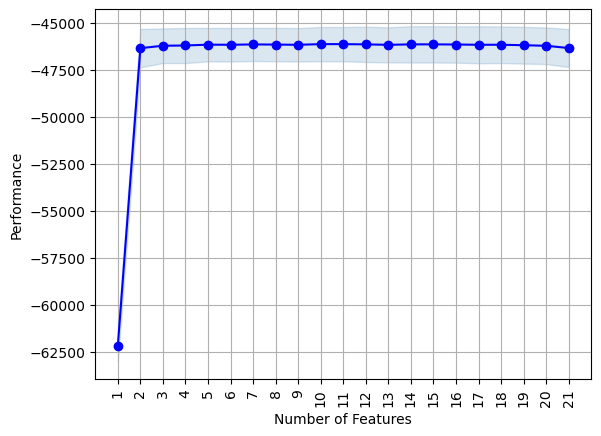

In [88]:
# Performa model dengan menggunakan feature berjumlah 1-10 
plot_sfs(sfs_mlxtend_forward.get_metric_dict(), kind='std_err')
plt.grid()

plt.xticks(rotation=90)

plt.show()

In [89]:
Xtrain_sfs = Xtrain_scaled_df.iloc[:,best_index]
Xtest_sfs = Xtest_scaled_df.iloc[:,best_index]

In [90]:
Xtrain_sfs

,TimeToSubway_10min~15min,TimeToSubway_5min~10min,SubwayStation_Bangoge,SubwayStation_Banwoldang,SubwayStation_Kyungbuk_uni_hospital,SubwayStation_Myung-duk,N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,Size(sqf)
0,0.0,0.0,0.0,0.0,1.0,0.0,0.5,0.5,0.638574,0.500000,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,-0.5,0.0,-0.098865,0.142857,-0.191038
2,0.0,0.0,0.0,0.0,1.0,0.0,0.5,0.5,0.638574,0.500000,0.000000
3,0.0,1.0,1.0,0.0,0.0,0.0,0.5,1.0,0.424635,-0.071429,0.009434
4,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-0.5,-0.539708,0.214286,0.589623
...,...,...,...,...,...,...,...,...,...,...,...
2155,0.0,0.0,0.0,0.0,1.0,0.0,0.5,0.5,0.638574,0.500000,-0.007075
2156,0.0,0.0,0.0,0.0,0.0,1.0,1.5,1.5,1.034036,0.571429,0.000000
2157,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.5,0.000000,-0.928571,1.275943
2158,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.5,0.000000,-0.928571,-0.627358


In [92]:
model_sfs  = gradient

model_sfs.fit(Xtrain_sfs,ytrain)

y_pred_train = model_sfs.predict(Xtrain_sfs)

y_pred_test = model_sfs.predict(Xtest_sfs)



rmse = root_mean_squared_error(ytest,y_pred_test) # Ensure ytest is defined
mae = mean_absolute_error(ytest,y_pred_test)
r2 = r2_score(ytest,y_pred_test)
mape = mean_absolute_percentage_error(ytest,y_pred_test) * 100  # MAPE in percentage

print('SFS Model Score:')
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}")

SFS Model Score:
RMSE: 46249.29904
MAE: 36961.06893
R²: 0.81173
MAPE: 18.27178


In [93]:

test_result = root_mean_squared_error(ytest,y_pred_test)
test_result_r2 = r2_score(ytest,y_pred_test)

train_result = root_mean_squared_error(ytrain,y_pred_train)
train_result_r2 = r2_score(ytrain,y_pred_train)

In [94]:

treatment1 = {'model': 'SFS Forward', 
                        'Test RMSE': test_result,
                        'Train RMSE': train_result,
                        'Test R2': test_result_r2,
                        'Train R2': train_result_r2}

treatment = pd.concat([treatment, pd.DataFrame([treatment1])], ignore_index=True)



In [95]:
# Best RMSE
treatment.sort_values('Test RMSE')

,model,Test RMSE,Train RMSE,Test R2,Train R2
2,SFS Forward,46249.299043,44687.892315,0.811730,0.817710
0,Benchmark,46305.213031,44576.466993,0.811275,0.818618
1,Important Feature only,46423.077604,44589.567746,0.810313,0.818512


In [96]:
# Best R2
treatment.sort_values('Test R2', ascending=False)

,model,Test RMSE,Train RMSE,Test R2,Train R2
2,SFS Forward,46249.299043,44687.892315,0.811730,0.817710
0,Benchmark,46305.213031,44576.466993,0.811275,0.818618
1,Important Feature only,46423.077604,44589.567746,0.810313,0.818512


Through experimenting with the features of our best model (Benchmark), we can see that the second treatment of using SFS forward method and our benchamark gives the highest R2 with the least RMSE score. We can cocnlude that our best model is the benchmark model

# Intepretation

In [ ]:
model_sfs  = gradient

model_sfs.fit(Xtrain_sfs,ytrain)

y_pred_train = model_sfs.predict(Xtrain_sfs)

y_pred_test = model_sfs.predict(Xtest_sfs)



rmse = root_mean_squared_error(ytest,y_pred_test) # Ensure ytest is defined
mae = mean_absolute_error(ytest,y_pred_test)
r2 = r2_score(ytest,y_pred_test)
mape = mean_absolute_percentage_error(ytest,y_pred_test) * 100  # MAPE in percentage

print('SFS Model Score:')
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}")

SFS Model Score:
RMSE: 46249.29904
MAE: 36961.06893
R²: 0.81173
MAPE: 18.27178


In [ ]:
df_error = pd.DataFrame(
    {'y_pred':y_pred_test,
    'error' : (ytest - y_pred_test)}
)
df_error


,y_pred,error
94,214172.018032,-62845.018032
3056,156541.526423,-37072.526423
1081,169433.716922,50035.283078
2361,347135.093475,2421.906525
1664,138706.596079,20585.403921
...,...,...
3360,370587.436735,89588.563265
2033,212338.560566,64652.439434
415,178204.762159,12502.237841
1377,252718.643700,12767.356300


<Axes: xlabel='y_pred', ylabel='error'>

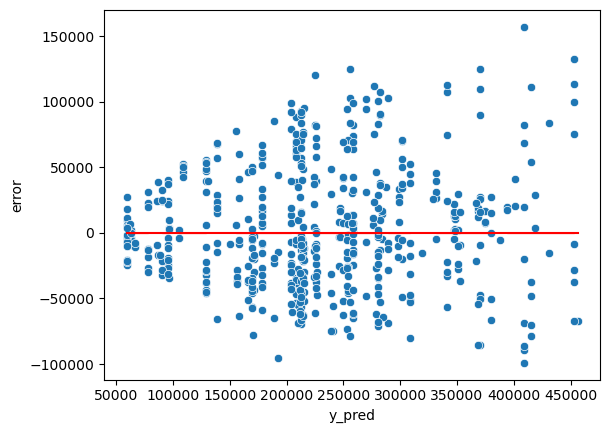

In [ ]:
sns.scatterplot(df_error, x='y_pred', y='error')
sns.lineplot(df_error, x='y_pred', y=0, color = 'red')

In this case, there appears to be some heteroscedasticity (increasing spread as y_pred increases), meaning the model’s error grows for higher predicted values. This could indicate that the model struggles to predict larger values accurately.

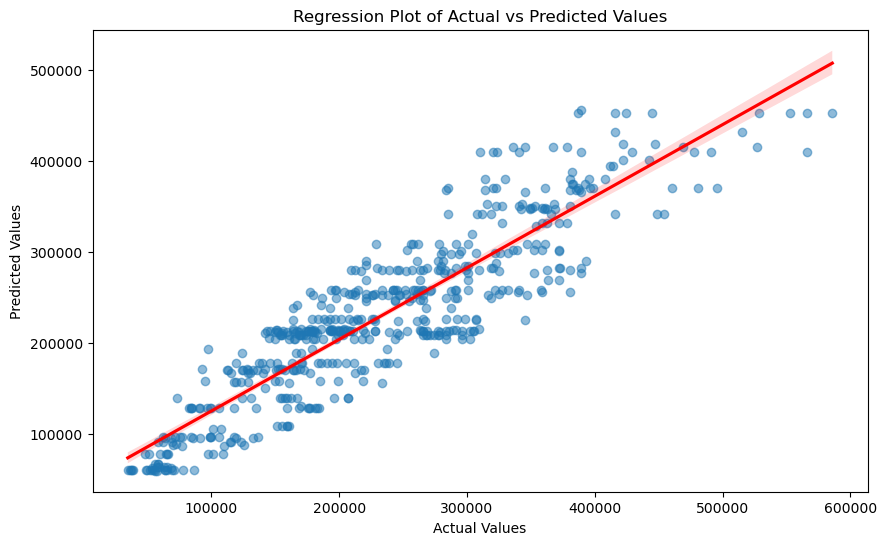

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x=ytest, y=y_pred_test, scatter_kws={'alpha':0.5},line_kws={'color': 'red'})
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Regression Plot of Actual vs Predicted Values')
plt.show()

## SHAP 

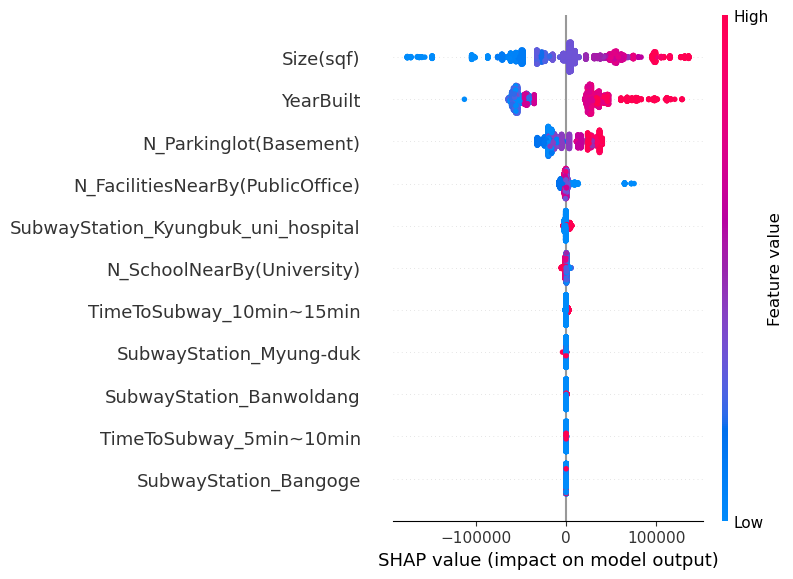

In [ ]:
# Create a SHAP explainer
explainer = shap.TreeExplainer(model_sfs)

# Calculate SHAP values for the training data
shap_values = explainer.shap_values(Xtrain_sfs)

# Plot summary plot
shap.summary_plot(shap_values, Xtrain_sfs)


Features like larger size, newer constructions, more parking, proximity to public offices, universities, and certain subway stations positively influence the model's output, while longer subway travel times and the "Low" feature have negative impacts.

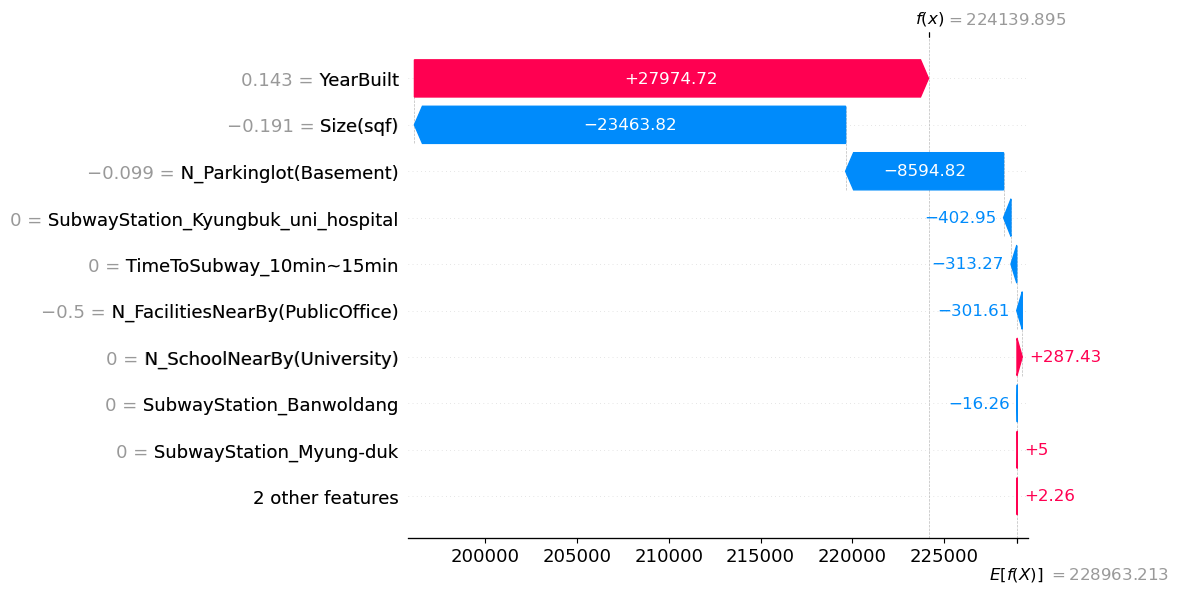

In [ ]:

explainer = shap.TreeExplainer(model)

# Select a single instance for which to generate the waterfall plot
instance = Xtrain_sfs.iloc[1]  # Example for the first row (adjust based on your need)

# Calculate SHAP values for this instance
shap_values = explainer.shap_values(instance)
shap_values_explanation = shap.Explanation(values=shap_values, 
                                           base_values=explainer.expected_value, 
                                           data=instance)

# Generate the Waterfall Plot
shap.waterfall_plot(shap_values_explanation)




- **Base Value (E(f(x)))**: 228,963.213 (average model output).
- **Predicted Value (f(x))**: 224,139.895 (specific instance prediction).

Feature Impacts:
- **YearBuilt**: Positive impact (+0.143) — newer constructions increase the value.
- **Size (sqf)**: Negative impact (-0.191) — larger sizes decrease the value.
- **N_Parkinglot (Basement)**: Slight negative impact (-0.099) — reduces the prediction.
- **N_FacilitiesNearBy (PublicOffice)**: Significant negative impact (-0.5) — fewer public facilities lower the value.
- **Other Features**: Subway stations and university proximity have no impact (0).

 Contributions:
- **Positive Contributions**: +28,974.72.
- **Negative Contributions**: -23,463.82.

Summary:
The predicted value is slightly below the average, influenced by larger sizes and fewer public facilities, despite some positive contributions from newer constructions and other minor features.

## Model Performance Overview

1. **R² = 81.17%**  
   This means that our model is able to explain about 81% of the factors that influence apartment prices in Daegu. In simple terms, it shows that the model does a good job in understanding the key patterns and relationships in the data.

2. **RMSE = 46,248**  
   On average, our predictions are off by around 46,248 units Won, meaning that for each prediction, the error is usually within this range. This gives us an idea of how much we can expect the model to fluctuate.

3. **MAE = 36,959**  
   The mean absolute error shows that, on average, our predictions are off by around 36,959 units Won. This is a simpler way of measuring the prediction accuracy without considering whether errors are positive or negative.

4. **MAPE = 18.27%**  
   This is the average percentage error in our predictions. It tells us that, on average, the model's predictions are off by around 18%. For instance, if an apartment price is predicted to be 200,000 units, the model’s error will be around 36,000 units on average.

---

## Business Interpretation

The model is performing well, explaining most of the variance in apartment prices, and the errors are relatively manageable. If the typical apartment price is high, a margin of error of about 18% may be acceptable. However, if prices fluctuate a lot or are generally lower, we may aim for even more accuracy. In any case, the model’s current performance is strong and can help make informed decisions about apartment pricing in Daegu. By leveraging this tool, owners can align their prices more closely with market trends, improving their chances of selling or renting their properties faster and at optimal prices. 

---

## Limitations
While the model is useful, there are areas for improvement:

### 1. **Hyperparameter Tuning**
- The current model uses **Random Search** for hyperparameter optimization, which is effective but not exhaustive. Switching to more advanced methods like **Grid Search** or **Bayesian Optimization** could yield better results by exploring the hyperparameter space more thoroughly.

### 2. **Feature Limitation**
- The model only considers limited amount of features, therefore if owners would like to predict features outside of the model (i.e Number of Police Station near the apartment), the model would not be able to predict it
- The model only considers limited range of numerical features, therefore if owners would like to predict numerical features outside of the model (i.e 11 Number of facilities) it would not be able to predict it as accurately
- The model could benefit from incorporating additional features that influence apartment prices, such as:
  - Proximity to parks, shopping centers, or hospitals.
  - Crime rates in the neighborhood.
  - Recent market trends or economic indicators.
- Including these features could improve the model's accuracy and predictive power.

### 3. **Data Quality and Quantity**
- The model's performance is limited by the quality and quantity of the data it is trained on. Collecting more high-quality, up-to-date data (e.g., recent transaction prices, detailed property descriptions) could enhance its accuracy.
- Heteroscedasticity is present in the error distribution, consider using log transformation or weighted regression..
### 4. **Model Complexity**
- While Gradient Boosting is powerful, it can be computationally expensive and time-consuming to train, especially with large datasets. Exploring lighter or more efficient algorithms (e.g., **LightGBM**, **XGBoost**) could improve scalability.

---

## Conclusion
The current model is a valuable tool for apartment owners on Platform A, offering a data-driven approach to pricing with a relatively low error rate. However, by addressing the limitations—such as improving hyperparameter tuning, adding more features, and enhancing data quality—the model's accuracy and usability can be further improved, making it an even more powerful asset for stakeholders in the real estate market.




# Appendix

## Saving model

In [97]:
Xtrain_sfs.columns

Index(['TimeToSubway_10min~15min', 'TimeToSubway_5min~10min',
       'SubwayStation_Bangoge', 'SubwayStation_Banwoldang',
       'SubwayStation_Kyungbuk_uni_hospital', 'SubwayStation_Myung-duk',
       'N_FacilitiesNearBy(PublicOffice)', 'N_SchoolNearBy(University)',
       'N_Parkinglot(Basement)', 'YearBuilt', 'Size(sqf)'],
      dtype='object')

In [98]:
Xtrain.columns

Index(['HallwayType', 'TimeToSubway', 'SubwayStation',
       'N_FacilitiesNearBy(ETC)', 'N_FacilitiesNearBy(PublicOffice)',
       'N_SchoolNearBy(University)', 'N_Parkinglot(Basement)', 'YearBuilt',
       'N_FacilitiesInApt', 'Size(sqf)'],
      dtype='object')

In [100]:
Xtrain_final = Xtrain[['TimeToSubway', 'SubwayStation','N_FacilitiesNearBy(PublicOffice)',
       'N_SchoolNearBy(University)', 'N_Parkinglot(Basement)', 'YearBuilt', 'Size(sqf)']].copy()

In [101]:
transformer_final = ColumnTransformer(
    [('onehot', OneHotEncoder(), ['TimeToSubway', 'SubwayStation']),
     ('robust',RobustScaler(), ['N_FacilitiesNearBy(PublicOffice)',
       'N_SchoolNearBy(University)', 'N_Parkinglot(Basement)', 'YearBuilt',
       'Size(sqf)'])]
)

transformer_final

ColumnTransformer(transformers=[('onehot', OneHotEncoder(),
                                 ['TimeToSubway', 'SubwayStation']),
                                ('robust', RobustScaler(),
                                 ['N_FacilitiesNearBy(PublicOffice)',
                                  'N_SchoolNearBy(University)',
                                  'N_Parkinglot(Basement)', 'YearBuilt',
                                  'Size(sqf)'])])

In [102]:
final_model = Pipeline([
        ('preprocessing', transformer_final),
        ('model', gradient)
    ])

final_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot', OneHotEncoder(),
                                                  ['TimeToSubway',
                                                   'SubwayStation']),
                                                 ('robust', RobustScaler(),
                                                  ['N_FacilitiesNearBy(PublicOffice)',
                                                   'N_SchoolNearBy(University)',
                                                   'N_Parkinglot(Basement)',
                                                   'YearBuilt',
                                                   'Size(sqf)'])])),
                ('model', GradientBoostingRegressor(random_state=0))])

In [103]:
model_final = final_model

# fit
model_final.fit(Xtrain_final, ytrain)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('onehot', OneHotEncoder(),
                                                  ['TimeToSubway',
                                                   'SubwayStation']),
                                                 ('robust', RobustScaler(),
                                                  ['N_FacilitiesNearBy(PublicOffice)',
                                                   'N_SchoolNearBy(University)',
                                                   'N_Parkinglot(Basement)',
                                                   'YearBuilt',
                                                   'Size(sqf)'])])),
                ('model', GradientBoostingRegressor(random_state=0))])

In [104]:
import pickle

pickle.dump(model_final, open('final_model.sav','wb'))